# Fair Small-Data Ariel Experiment: CPU Comparison

This notebook reuses the saved CPU sweep under `fair_small_experiment_cpu/20260312_131726` and plots finished conditions from that run by default.

Set `RUN_TRAINING = True` if you want the notebook to train missing conditions or create a new run. Otherwise it stays in read-only comparison mode using saved outputs.

In [2]:
from pathlib import Path
import sys

expected_python = Path.cwd() / ".venv" / "bin" / "python"
print("Python executable:", sys.executable)
if expected_python.exists() and Path(sys.executable).resolve() != expected_python.resolve():
    raise RuntimeError(
        "Wrong notebook kernel. Switch to `Python (.venv AXION notebooks)` and rerun. "
        f"Expected: {expected_python} | Current: {sys.executable}"
    )

Python executable: /Users/mariaplatek/projects/AXION/notebooks/.venv/bin/python


In [4]:
from __future__ import annotations

import importlib.util
import json
import os
import platform
import random
import shutil
import sys
from datetime import datetime
from pathlib import Path
import time

import numpy as np
import torch

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "hack4sages.code-workspace").exists():
            return candidate
        if (candidate / ".git").exists() and (candidate / "data" / "ariel-ml-dataset").exists():
            return candidate
        if (candidate / "README.md").exists() and (candidate / "data" / "ariel-ml-dataset").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root.")

def find_data_root(project_root: Path) -> Path:
    override = os.environ.get("ARIEL_DATA_ROOT")
    if override:
        root = Path(override).expanduser().resolve()
        if root.exists():
            return root
    for candidate in [
        project_root / "data" / "ariel-ml-dataset",
        project_root / "ariel-ml-dataset",
        project_root.parent / "data" / "ariel-ml-dataset",
        project_root.parent / "ariel-ml-dataset",
    ]:
        if (candidate / "TrainingData" / "AuxillaryTable.csv").exists() and (candidate / "TrainingData" / "SpectralData.hdf5").exists():
            return candidate
    raise FileNotFoundError("Could not locate ADC2023 dataset root.")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_ROOT = find_data_root(PROJECT_ROOT)

# Default to read-only comparison from an existing run.
# Flip RUN_TRAINING to True when you want to generate or refresh outputs.
RUN_TRAINING = False
EXISTING_RUN_TAG = "20260312_131726"
NEW_RUN_TAG = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_TAG = NEW_RUN_TAG if RUN_TRAINING else EXISTING_RUN_TAG
OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "fair_small_experiment_cpu" / RUN_TAG
if RUN_TRAINING:
    OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

SEED = 42
VALIDATION_ROWS = 64
HOLDOUT_ROWS = 64

# Keep the full grid so completed conditions are reloaded into the summary tables.
RUNTIME_SECONDS_LIST = [60, 120, 300, 400]
TRAIN_ROWS_LIST = [64, 128, 256]

HIGH_MAX_EPOCHS = 500

# ExoBiome: fraction of total runtime for stage 1 (classical); rest goes to stage 2 (quantum).
# Stage 2 must always run, so stage1 fraction < 1.0 and stage2 gets meaningful time.
CODEX_STAGE1_FRACTION = 0.25
MIN_STAGE2_SECONDS = 10.0

# hyperparameters
CODEX_QNN_QUBITS = 8
CODEX_QNN_DEPTH = 2
CODEX_STAGE1_BATCH_SIZE = 256
CODEX_STAGE1_EVAL_BATCH_SIZE = 512
CODEX_STAGE1_EARLY_STOP = 10
CODEX_STAGE1_SCHEDULER_PATIENCE = 2
CODEX_STAGE1_CLASSICAL_LR = 1.0e-3
CODEX_STAGE2_BATCH_SIZE = 16
CODEX_STAGE2_EVAL_BATCH_SIZE = 32
CODEX_STAGE2_EARLY_STOP = 8
CODEX_STAGE2_SCHEDULER_PATIENCE = 3
CODEX_STAGE2_CLASSICAL_LR = 5.0e-5
CODEX_STAGE2_QUANTUM_LR = 2.0e-4
CODEX_STAGE2_WARMUP_EPOCHS = 0
CODEX_STAGE2_RAMP_EPOCHS = 12
CODEX_STAGE2_FREEZE_EPOCHS = 6
CODEX_DROPOUT = 0.05
CODEX_WEIGHT_DECAY = 1.0e-4
CODEX_GRADIENT_CLIP = 5.0
CODEX_QNN_INIT_SCALE = 0.1
CODEX_USE_AMP = True
CODEX_LOG_EVERY_BATCHES = 20

FMPE_PATIENCE = 500
FMPE_BATCH_SIZE = 64
FMPE_EVAL_BATCH_SIZE = 128
FMPE_POSTERIOR_SAMPLES = 32
FMPE_PERIODIC_SAMPLES = 16
FMPE_CONTEXT_BATCH_SIZE = 16

DEVICE = torch.device("cpu")
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

config = {
    "project_root": str(PROJECT_ROOT),
    "data_root": str(DATA_ROOT),
    "run_training": RUN_TRAINING,
    "existing_run_tag": EXISTING_RUN_TAG,
    "run_tag": RUN_TAG,
    "output_root": str(OUTPUT_ROOT),
    "runtime_seconds_list": RUNTIME_SECONDS_LIST,
    "train_rows_list": TRAIN_ROWS_LIST,
    "high_max_epochs": HIGH_MAX_EPOCHS,
    "ExoBiome_stage1_fraction": CODEX_STAGE1_FRACTION,
    "min_stage2_seconds": MIN_STAGE2_SECONDS,
}
print(json.dumps(config, indent=2))

{
  "project_root": "/Users/mariaplatek/projects/AXION/notebooks",
  "data_root": "/Users/mariaplatek/projects/AXION/notebooks/data/ariel-ml-dataset",
  "run_training": false,
  "existing_run_tag": "20260312_131726",
  "run_tag": "20260312_131726",
  "output_root": "/Users/mariaplatek/projects/AXION/notebooks/outputs/fair_small_experiment_cpu/20260312_131726",
  "runtime_seconds_list": [
    60,
    120,
    300,
    400
  ],
  "train_rows_list": [
    64,
    128,
    256
  ],
  "high_max_epochs": 500,
  "ExoBiome_stage1_fraction": 0.25,
  "min_stage2_seconds": 10.0
}


In [5]:
# Dependencies and imports
required_modules = {
    "numpy": "numpy", "pandas": "pandas", "h5py": "h5py", "PyYAML": "yaml",
    "PyTorch": "torch", "scikit-learn": "sklearn", "PennyLane": "pennylane", "Dingo": "dingo",
}
missing = [label for label, mod in required_modules.items() if importlib.util.find_spec(mod) is None]
if missing:
    raise RuntimeError(f"Missing: {missing}")

import h5py
import pandas as pd
import pennylane as qml
import yaml
from sklearn.model_selection import train_test_split

from models.sbi_ariel_adc2023.constants import (
    AUX_FEATURE_COLS as FMPE_AUX_FEATURE_COLS,
    CONTEXT_DIM,
    CONTEXT_FILENAME_TEMPLATE,
    DATASET_TYPE,
    HOLDOUT_SPLIT,
    LOG10_AUX_FEATURE_COLS as FMPE_LOG10_AUX_FEATURE_COLS,
    MANIFEST_FILENAME,
    METADATA_FILENAME_TEMPLATE,
    NORMALIZATION_FILENAME,
    NORMALIZATION_MODE,
    RAW_TARGET_FILENAME_TEMPLATE,
    TARGET_COLS,
    TARGET_FILENAME_TEMPLATE,
    TESTDATA_SPLIT,
    THETA_DIM,
    TRAIN_SPLIT,
    VALIDATION_SPLIT,
    WAVELENGTH_FILENAME,
)
from models.sbi_ariel_adc2023.evaluate import run_regression_evaluation
from models.ariel_quantum_regression.constants import (
    AUX_COLUMNS as CODEX_AUX_COLUMNS,
    FIXED_SPECTRAL_CHANNELS,
    HDF5_GROUP_PREFIX,
    LOG10_AUX_COLUMNS as CODEX_LOG10_AUX_COLUMNS,
    MODEL_SPECTRAL_CHANNELS,
    PRESENCE_THRESHOLD_LOG10_VMR,
    RAW_SPECTRAL_CHANNELS,
    SAMPLE_SPECTRAL_CHANNELS,
    TARGET_COLUMNS as CODEX_TARGET_COLUMNS,
    WAVELENGTH_DATASET,
)
from models.ariel_quantum_regression.dataset import (
    ArrayStandardizer,
    PreparedData,
    SpectralStandardizer,
    _expected_manifest,
    _make_inference_split,
    _make_labeled_split,
    _normalize_fixed_channel,
    _normalize_sample_spectra,
    _save_prepared_cache,
    build_stratify_labels,
    transform_aux_features,
)

import importlib
import models.sbi_ariel_adc2023.training as fmpe_training_module
import models.ariel_quantum_regression.training as codex_training_module
importlib.reload(fmpe_training_module)
importlib.reload(codex_training_module)

# Force ExoBiome to stay on CPU for both stages, regardless of MPS/CUDA availability.
def force_cpu_training_device(config):
    return torch.device("cpu")

codex_training_module.resolve_training_device = force_cpu_training_device
train_model = fmpe_training_module.train_model
TrainingConfig = codex_training_module.TrainingConfig
run_training_experiment = codex_training_module.run_training_experiment

QUANTUM_DEVICE = "lightning.qubit"
CODEX_USE_AMP = False
print(f"Device: {DEVICE} | Quantum backend: {QUANTUM_DEVICE} | ExoBiome forced device: cpu")

Device: cpu | Quantum backend: lightning.qubit | ExoBiome forced device: cpu


In [6]:
def _drop_unnamed_columns(frame: pd.DataFrame) -> pd.DataFrame:
    unnamed = [c for c in frame.columns if c.startswith("Unnamed:")]
    if unnamed:
        frame = frame.drop(columns=unnamed)
    return frame

def _load_spectra(hdf5_path: Path, planet_ids: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    spectra = np.empty((len(planet_ids), 52, len(RAW_SPECTRAL_CHANNELS)), dtype=np.float32)
    wavelength_um = None
    with h5py.File(hdf5_path, "r") as handle:
        for row_index, planet_id in enumerate(planet_ids.tolist()):
            group = handle[f"{HDF5_GROUP_PREFIX}{planet_id}"]
            row_wavelength = np.asarray(group[WAVELENGTH_DATASET][:], dtype=np.float32)
            if wavelength_um is None:
                wavelength_um = row_wavelength
            elif not np.allclose(row_wavelength, wavelength_um, atol=1.0e-8):
                raise AssertionError(f"Wavelength mismatch for {planet_id}")
            for channel_index, channel_name in enumerate(RAW_SPECTRAL_CHANNELS):
                spectra[row_index, :, channel_index] = np.asarray(group[channel_name][:], dtype=np.float32)
    if wavelength_um is None:
        raise RuntimeError(f"No spectra found in {hdf5_path}")
    return spectra, wavelength_um

train_aux_df = _drop_unnamed_columns(pd.read_csv(DATA_ROOT / "TrainingData" / "AuxillaryTable.csv"))
train_targets_df = _drop_unnamed_columns(
    pd.read_csv(DATA_ROOT / "TrainingData" / "Ground Truth Package" / "FM_Parameter_Table.csv")
)
labels = train_aux_df.merge(train_targets_df[["planet_ID", *TARGET_COLS]], on="planet_ID", how="inner", validate="one_to_one")
labels = labels.reset_index(drop=True)

train_spectra_raw, wavelength_um = _load_spectra(
    DATA_ROOT / "TrainingData" / "SpectralData.hdf5",
    labels["planet_ID"].to_numpy(dtype="U32"),
)
test_aux_df = _drop_unnamed_columns(pd.read_csv(DATA_ROOT / "TestData" / "AuxillaryTable.csv"))
test_spectra_raw, test_wavelength_um = _load_spectra(
    DATA_ROOT / "TestData" / "SpectralData.hdf5",
    test_aux_df["planet_ID"].to_numpy(dtype="U32"),
)
assert np.allclose(wavelength_um, test_wavelength_um, atol=1.0e-8), "Wavelength grids do not match."
targets_raw = labels[TARGET_COLS].to_numpy(dtype=np.float32, copy=True)
print(f"Training rows: {len(labels):,} | Test rows: {len(test_aux_df):,} | Wavelength bins: {len(wavelength_um)}")

Training rows: 41,423 | Test rows: 685 | Wavelength bins: 52


In [7]:
# Fixed train/val/holdout pools (same split logic as fair_small_compare)
all_indices = np.arange(len(labels), dtype=np.int64)
stratify_all, stratify_mode_all = build_stratify_labels(targets_raw)
train_pool, temp_pool = train_test_split(
    all_indices, test_size=0.2, random_state=SEED, shuffle=True,
    stratify=stratify_all if stratify_all is not None else None,
)
temp_targets_raw = targets_raw[temp_pool]
stratify_temp, stratify_mode_temp = build_stratify_labels(temp_targets_raw)
temp_positions = np.arange(len(temp_pool), dtype=np.int64)
validation_positions, holdout_positions = train_test_split(
    temp_positions, test_size=0.5, random_state=SEED + 1, shuffle=True,
    stratify=stratify_temp if stratify_temp is not None else None,
)
validation_pool = temp_pool[validation_positions]
holdout_pool = temp_pool[holdout_positions]
rng = np.random.default_rng(SEED)

def take_subset(indices: np.ndarray, limit: int) -> np.ndarray:
    if limit >= len(indices):
        return np.sort(indices.astype(np.int64))
    chosen = rng.choice(indices, size=int(limit), replace=False)
    return np.sort(chosen.astype(np.int64))

print("Pools ready. Use take_subset(train_pool, n) for each train_rows in the grid.")

Pools ready. Use take_subset(train_pool, n) for each train_rows in the grid.


In [8]:
def safe_scale(values: np.ndarray) -> np.ndarray:
    scale = values.std(axis=0, ddof=0).astype(np.float32)
    return np.where(scale == 0.0, 1.0, scale).astype(np.float32)

def normalize_spectrum(values: np.ndarray) -> np.ndarray:
    sample_mean = values.mean(axis=1, keepdims=True)
    sample_mean = np.clip(sample_mean, 1.0e-12, None)
    return (values / sample_mean).astype(np.float32)

def log_noise(values: np.ndarray) -> np.ndarray:
    return np.log10(np.clip(values.astype(np.float32), 1.0e-12, None)).astype(np.float32)

def compute_zscore(values: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    mean = values.mean(axis=0).astype(np.float32)
    scale = safe_scale(values)
    return mean, scale

def apply_zscore(values: np.ndarray, mean: np.ndarray, scale: np.ndarray) -> np.ndarray:
    return ((values - mean) / scale).astype(np.float32)

def metadata_frame(indices: np.ndarray) -> pd.DataFrame:
    return pd.DataFrame({
        "planet_ID": labels.iloc[indices]["planet_ID"].to_numpy(dtype="U32"),
        "source_row_index": indices.astype(np.int64),
    })

def build_prepared_data(experiment_dir: Path, train_idx: np.ndarray, validation_idx: np.ndarray, holdout_idx: np.ndarray):
    """Build shared split, ExoBiome cache, and ADC_5 prepared dataset for given indices. Returns (codex_cache_dir, fmpe_prepared_dir, shared_split_path)."""
    experiment_dir = Path(experiment_dir)
    experiment_dir.mkdir(parents=True, exist_ok=True)
    shared_split_path = experiment_dir / "shared_split.csv"
    split_frame = pd.DataFrame({
        "split": ([TRAIN_SPLIT] * len(train_idx)) + ([VALIDATION_SPLIT] * len(validation_idx)) + ([HOLDOUT_SPLIT] * len(holdout_idx)),
        "planet_ID": np.concatenate([
            labels.iloc[train_idx]["planet_ID"].to_numpy(dtype="U32"),
            labels.iloc[validation_idx]["planet_ID"].to_numpy(dtype="U32"),
            labels.iloc[holdout_idx]["planet_ID"].to_numpy(dtype="U32"),
        ]),
        "source_row_index": np.concatenate([train_idx, validation_idx, holdout_idx]),
    })
    split_frame.to_csv(shared_split_path, index=False)
    (experiment_dir / "shared_split_manifest.json").write_text(
        json.dumps({"seed": SEED, "train_rows": len(train_idx), "validation_rows": len(validation_idx), "holdout_rows": len(holdout_idx), "shared_split_file": str(shared_split_path)}, indent=2) + "\n"
    )

    # ExoBiome
    codex_cache_dir = experiment_dir / "codex_prepared_cache"
    if codex_cache_dir.exists():
        shutil.rmtree(codex_cache_dir)
    codex_cache_dir.mkdir(parents=True, exist_ok=True)
    codex_aux_raw = transform_aux_features(labels)
    codex_test_aux_raw = transform_aux_features(test_aux_df)
    codex_targets_raw = labels[CODEX_TARGET_COLUMNS].to_numpy(dtype=np.float32, copy=True)
    sample_channel_indices = [RAW_SPECTRAL_CHANNELS.index(n) for n in SAMPLE_SPECTRAL_CHANNELS]
    width_channel_index = RAW_SPECTRAL_CHANNELS.index("instrument_width")
    codex_train_sample_spectra = np.transpose(train_spectra_raw[:, :, sample_channel_indices], (0, 2, 1)).astype(np.float32)
    codex_test_sample_spectra = np.transpose(test_spectra_raw[:, :, sample_channel_indices], (0, 2, 1)).astype(np.float32)
    codex_train_sample_spectra = _normalize_sample_spectra(codex_train_sample_spectra)
    codex_test_sample_spectra = _normalize_sample_spectra(codex_test_sample_spectra)
    fixed_channels = np.stack([
        _normalize_fixed_channel(train_spectra_raw[0, :, width_channel_index]),
        _normalize_fixed_channel(wavelength_um),
    ], axis=0).astype(np.float32)
    codex_aux_scaler = ArrayStandardizer.fit(codex_aux_raw[train_idx])
    codex_target_scaler = ArrayStandardizer.fit(codex_targets_raw[train_idx])
    codex_spectral_scaler = SpectralStandardizer.fit(codex_train_sample_spectra[train_idx], fixed_channels=fixed_channels)

    def make_codex_labeled_split(indices):
        return _make_labeled_split(
            planet_ids=labels.iloc[indices]["planet_ID"].to_numpy(dtype="U32"),
            aux_values=codex_aux_scaler.transform(codex_aux_raw[indices]),
            spectra_values=codex_spectral_scaler.transform(codex_train_sample_spectra[indices]),
            targets_scaled=codex_target_scaler.transform(codex_targets_raw[indices]),
            raw_targets=codex_targets_raw[indices],
        )
    codex_test_split = _make_inference_split(
        planet_ids=test_aux_df["planet_ID"].to_numpy(dtype="U32"),
        aux_values=codex_aux_scaler.transform(codex_test_aux_raw),
        spectra_values=codex_spectral_scaler.transform(codex_test_sample_spectra),
    )
    codex_split_manifest = {
        "train_rows": len(train_idx), "val_rows": len(validation_idx), "holdout_rows": len(holdout_idx),
        "shared_split_file": str(shared_split_path),
        "wavelength_bins": len(wavelength_um), "target_columns": CODEX_TARGET_COLUMNS,
    }
    codex_expected_manifest = _expected_manifest(DATA_ROOT, SEED, len(train_idx), len(validation_idx), len(holdout_idx), None)
    codex_prepared_manifest = dict(codex_expected_manifest)
    codex_prepared_manifest["cache_dir"] = str(codex_cache_dir)
    codex_prepared_manifest["cache_hit"] = False
    codex_prepared = PreparedData(
        train=make_codex_labeled_split(train_idx), val=make_codex_labeled_split(validation_idx),
        holdout=make_codex_labeled_split(holdout_idx), testdata=codex_test_split,
        aux_scaler=codex_aux_scaler, target_scaler=codex_target_scaler, spectral_scaler=codex_spectral_scaler,
        wavelength_um=wavelength_um.astype(np.float32), split_manifest=codex_split_manifest, prepared_manifest=codex_prepared_manifest,
    )
    _save_prepared_cache(codex_cache_dir, codex_expected_manifest, codex_prepared)

    # ADC_5
    fmpe_prepared_dir = experiment_dir / "fmpe_prepared_dataset"
    if fmpe_prepared_dir.exists():
        shutil.rmtree(fmpe_prepared_dir)
    fmpe_prepared_dir.mkdir(parents=True, exist_ok=True)
    fmpe_labeled_spectrum = normalize_spectrum(train_spectra_raw[:, :, RAW_SPECTRAL_CHANNELS.index("instrument_spectrum")])
    fmpe_test_spectrum = normalize_spectrum(test_spectra_raw[:, :, RAW_SPECTRAL_CHANNELS.index("instrument_spectrum")])
    fmpe_labeled_noise = log_noise(train_spectra_raw[:, :, RAW_SPECTRAL_CHANNELS.index("instrument_noise")])
    fmpe_test_noise = log_noise(test_spectra_raw[:, :, RAW_SPECTRAL_CHANNELS.index("instrument_noise")])
    fmpe_labeled_aux = labels[FMPE_AUX_FEATURE_COLS].to_numpy(dtype=np.float32, copy=True)
    fmpe_test_aux = test_aux_df[FMPE_AUX_FEATURE_COLS].to_numpy(dtype=np.float32, copy=True)
    for col_index, col_name in enumerate(FMPE_AUX_FEATURE_COLS):
        if col_name in FMPE_LOG10_AUX_FEATURE_COLS:
            fmpe_labeled_aux[:, col_index] = np.log10(np.clip(fmpe_labeled_aux[:, col_index], 1.0e-12, None))
            fmpe_test_aux[:, col_index] = np.log10(np.clip(fmpe_test_aux[:, col_index], 1.0e-12, None))
    fmpe_targets_raw = labels[TARGET_COLS].to_numpy(dtype=np.float32, copy=True)
    spectrum_mean, spectrum_scale = compute_zscore(fmpe_labeled_spectrum[train_idx])
    noise_mean, noise_scale = compute_zscore(fmpe_labeled_noise[train_idx])
    aux_mean, aux_scale = compute_zscore(fmpe_labeled_aux[train_idx])
    target_mean, target_scale = compute_zscore(fmpe_targets_raw[train_idx])

    def fmpe_context(indices):
        return np.concatenate([
            apply_zscore(fmpe_labeled_spectrum[indices], spectrum_mean, spectrum_scale),
            apply_zscore(fmpe_labeled_noise[indices], noise_mean, noise_scale),
            apply_zscore(fmpe_labeled_aux[indices], aux_mean, aux_scale),
        ], axis=1).astype(np.float32)

    def write_fmpe_split(split_name, indices):
        np.save(fmpe_prepared_dir / CONTEXT_FILENAME_TEMPLATE.format(split_name=split_name), fmpe_context(indices))
        np.save(fmpe_prepared_dir / TARGET_FILENAME_TEMPLATE.format(split_name=split_name), apply_zscore(fmpe_targets_raw[indices], target_mean, target_scale))
        np.save(fmpe_prepared_dir / RAW_TARGET_FILENAME_TEMPLATE.format(split_name=split_name), fmpe_targets_raw[indices].astype(np.float32))
        metadata_frame(indices).to_csv(fmpe_prepared_dir / METADATA_FILENAME_TEMPLATE.format(split_name=split_name), index=False)
    write_fmpe_split(TRAIN_SPLIT, train_idx)
    write_fmpe_split(VALIDATION_SPLIT, validation_idx)
    write_fmpe_split(HOLDOUT_SPLIT, holdout_idx)
    test_context = np.concatenate([
        apply_zscore(fmpe_test_spectrum, spectrum_mean, spectrum_scale),
        apply_zscore(fmpe_test_noise, noise_mean, noise_scale),
        apply_zscore(fmpe_test_aux, aux_mean, aux_scale),
    ], axis=1).astype(np.float32)
    np.save(fmpe_prepared_dir / CONTEXT_FILENAME_TEMPLATE.format(split_name=TESTDATA_SPLIT), test_context)
    pd.DataFrame({"planet_ID": test_aux_df["planet_ID"].to_numpy(dtype="U32"), "source_row_index": np.arange(len(test_aux_df), dtype=np.int64)}).to_csv(fmpe_prepared_dir / METADATA_FILENAME_TEMPLATE.format(split_name=TESTDATA_SPLIT), index=False)
    np.savez(fmpe_prepared_dir / NORMALIZATION_FILENAME, spectrum_mean=spectrum_mean, spectrum_scale=spectrum_scale, noise_mean=noise_mean, noise_scale=noise_scale, aux_mean=aux_mean, aux_scale=aux_scale, target_mean=target_mean, target_scale=target_scale)
    np.save(fmpe_prepared_dir / WAVELENGTH_FILENAME, wavelength_um.astype(np.float32))
    (fmpe_prepared_dir / MANIFEST_FILENAME).write_text(json.dumps({
        "data_root": str(DATA_ROOT), "prepared_dir": str(fmpe_prepared_dir), "dataset_type": DATASET_TYPE, "normalization_mode": NORMALIZATION_MODE,
        "seed": SEED, "split_counts": {TRAIN_SPLIT: len(train_idx), VALIDATION_SPLIT: len(validation_idx), HOLDOUT_SPLIT: len(holdout_idx), TESTDATA_SPLIT: len(test_aux_df)},
        "context_dim": CONTEXT_DIM, "theta_dim": THETA_DIM, "target_columns": TARGET_COLS, "shared_split_file": str(shared_split_path),
    }, indent=2, sort_keys=True) + "\n")
    return codex_cache_dir, fmpe_prepared_dir, shared_split_path

In [9]:
# Load experiment grid only from saved outputs; do not rerun training.
results = []
for runtime_seconds in RUNTIME_SECONDS_LIST:
    for train_rows in TRAIN_ROWS_LIST:
        experiment_dir = OUTPUT_ROOT / f"runtime_{runtime_seconds}s_data_{train_rows}"
        codex_out = experiment_dir / "codex"
        stage1_dir = codex_out / "stage1_classical"
        stage2_dir = codex_out / "stage2_hybrid"
        fmpe_out = experiment_dir / "fmpe"

        stage1_summary_path = stage1_dir / "run_summary.json"
        stage2_summary_path = stage2_dir / "run_summary.json"
        fmpe_metrics_path = fmpe_out / "holdout_regression_metrics.json"
        posterior_selection_path = fmpe_out / "posterior_selection.json"
        condition_complete = (
            stage1_summary_path.exists()
            and stage2_summary_path.exists()
            and fmpe_metrics_path.exists()
            and posterior_selection_path.exists()
        )

        if condition_complete:
            stage1_summary = json.loads(stage1_summary_path.read_text())
            stage2_summary = json.loads(stage2_summary_path.read_text())
            fmpe_holdout_metrics = json.loads(fmpe_metrics_path.read_text())
            point_estimate = json.loads(posterior_selection_path.read_text()).get("selected_point_estimate", "mean")
            fmpe_holdout_rmse = float(fmpe_holdout_metrics[point_estimate]["rmse_mean"])
            codex_holdout_rmse = float(stage2_summary["holdout_rmse_mean"])
            codex_stage2_ran = int(stage2_summary.get("best_epoch", 0)) >= 1
            results.append({
                "runtime_seconds": runtime_seconds,
                "train_rows": train_rows,
                "codex_holdout_rmse_mean": codex_holdout_rmse,
                "fmpe_holdout_rmse_mean": fmpe_holdout_rmse,
                "codex_stage2_ran": codex_stage2_ran,
                "codex_stage1_status": stage1_summary.get("status"),
                "codex_stage2_status": stage2_summary.get("status"),
            })
            print(f"Loaded saved outputs for runtime={runtime_seconds}s train_rows={train_rows}")
            continue

        if not RUN_TRAINING:
            print(
                f"Missing saved outputs for runtime={runtime_seconds}s train_rows={train_rows}. "
                "Set RUN_TRAINING = True to train this condition."
            )
            continue

        codex_cache_dir, fmpe_prepared_dir, _ = build_prepared_data(experiment_dir, train_idx, validation_idx, holdout_idx)

        # ExoBiome: stage1 budget so that stage2 always gets at least MIN_STAGE2_SECONDS and runs.
        stage1_budget = min(runtime_seconds * CODEX_STAGE1_FRACTION, max(1.0, runtime_seconds - MIN_STAGE2_SECONDS))
        if codex_out.exists():
            shutil.rmtree(codex_out)
        codex_out.mkdir(parents=True, exist_ok=True)

        def make_stage1_cfg(out_dir, budget_s):
            return TrainingConfig(
                project_root=str(PROJECT_ROOT), data_root=str(DATA_ROOT), output_dir=str(out_dir),
                prepared_cache_dir=str(codex_cache_dir), seed=SEED,
                batch_size=CODEX_STAGE1_BATCH_SIZE, eval_batch_size=CODEX_STAGE1_EVAL_BATCH_SIZE,
                max_epochs=HIGH_MAX_EPOCHS, max_runtime_seconds=budget_s,
                early_stop_patience=CODEX_STAGE1_EARLY_STOP, scheduler_patience=CODEX_STAGE1_SCHEDULER_PATIENCE, scheduler_factor=0.5,
                classical_lr=CODEX_STAGE1_CLASSICAL_LR, weight_decay=CODEX_WEIGHT_DECAY, gradient_clip_norm=CODEX_GRADIENT_CLIP,
                dropout=CODEX_DROPOUT, loss_name="mse", qnn_qubits=CODEX_QNN_QUBITS, qnn_depth=CODEX_QNN_DEPTH, qnn_init_scale=CODEX_QNN_INIT_SCALE,
                quantum_device=QUANTUM_DEVICE, classical_only=True, use_amp=CODEX_USE_AMP, log_every_batches=CODEX_LOG_EVERY_BATCHES,
                train_limit=len(train_idx), val_limit=len(validation_idx), holdout_limit=len(holdout_idx),
            )

        def make_stage2_cfg(out_dir, ckpt_path, budget_s):
            return TrainingConfig(
                project_root=str(PROJECT_ROOT), data_root=str(DATA_ROOT), output_dir=str(out_dir),
                prepared_cache_dir=str(codex_cache_dir), init_checkpoint_path=str(ckpt_path), seed=SEED,
                batch_size=CODEX_STAGE2_BATCH_SIZE, eval_batch_size=CODEX_STAGE2_EVAL_BATCH_SIZE,
                max_epochs=HIGH_MAX_EPOCHS, max_runtime_seconds=budget_s,
                early_stop_patience=CODEX_STAGE2_EARLY_STOP, scheduler_patience=CODEX_STAGE2_SCHEDULER_PATIENCE, scheduler_factor=0.5,
                classical_lr=CODEX_STAGE2_CLASSICAL_LR, quantum_lr=CODEX_STAGE2_QUANTUM_LR, weight_decay=CODEX_WEIGHT_DECAY,
                gradient_clip_norm=CODEX_GRADIENT_CLIP, dropout=CODEX_DROPOUT, loss_name="mse",
                qnn_qubits=CODEX_QNN_QUBITS, qnn_depth=CODEX_QNN_DEPTH, qnn_init_scale=CODEX_QNN_INIT_SCALE,
                quantum_device=QUANTUM_DEVICE, classical_only=False,
                quantum_warmup_epochs=CODEX_STAGE2_WARMUP_EPOCHS, quantum_ramp_epochs=CODEX_STAGE2_RAMP_EPOCHS, quantum_backbone_freeze_epochs=CODEX_STAGE2_FREEZE_EPOCHS,
                use_amp=CODEX_USE_AMP, log_every_batches=CODEX_LOG_EVERY_BATCHES,
                train_limit=len(train_idx), val_limit=len(validation_idx), holdout_limit=len(holdout_idx),
            )

        codex_start = time.perf_counter()
        stage1_cfg = make_stage1_cfg(stage1_dir, stage1_budget)
        stage1_result = run_training_experiment(stage1_cfg)
        stage1_ckpt = Path(stage1_dir) / "best_model.pt"
        if not stage1_ckpt.exists():
            raise FileNotFoundError(f"ExoBiome stage1 no checkpoint: {stage1_ckpt}")
        stage2_budget = max(MIN_STAGE2_SECONDS, runtime_seconds - (time.perf_counter() - codex_start))
        stage2_cfg = make_stage2_cfg(stage2_dir, stage1_ckpt.resolve(), stage2_budget)
        stage2_result = run_training_experiment(stage2_cfg)
        codex_holdout_rmse = float(stage2_result["summary"]["holdout_rmse_mean"])
        codex_stage2_ran = int(stage2_result["summary"].get("best_epoch", 0)) >= 1

        # ADC_5: same total runtime, high max_epochs so runtime stops first.
        if fmpe_out.exists():
            shutil.rmtree(fmpe_out)
        fmpe_out.mkdir(parents=True, exist_ok=True)
        fmpe_settings = yaml.safe_load((PROJECT_ROOT / "models" / "sbi_ariel_adc2023" / "settings" / "adc2023_rtx4090.yaml").read_text())
        fmpe_settings["dataset"]["path"] = str(fmpe_prepared_dir)
        fmpe_settings["training"]["device"] = "cpu"
        fmpe_settings["training"]["batch_size"] = FMPE_BATCH_SIZE
        fmpe_settings["training"]["eval_batch_size"] = FMPE_EVAL_BATCH_SIZE
        fmpe_settings["training"]["epochs"] = HIGH_MAX_EPOCHS
        fmpe_settings["training"]["patience"] = FMPE_PATIENCE
        fmpe_settings["training"]["max_runtime_seconds"] = float(runtime_seconds)
        fmpe_settings["training"]["num_workers"] = 0
        fmpe_settings["evaluation"]["device"] = "cpu"
        fmpe_settings["evaluation"]["run_after_training"] = False
        fmpe_settings["evaluation"]["posterior_samples"] = FMPE_POSTERIOR_SAMPLES
        fmpe_settings["evaluation"]["context_batch_size"] = FMPE_CONTEXT_BATCH_SIZE
        fmpe_settings["evaluation"]["periodic_rmse_every_epochs"] = 1
        fmpe_summary = train_model(settings=fmpe_settings, run_dir=fmpe_out, prepared_data_override=fmpe_prepared_dir, resume_mode="never")
        run_regression_evaluation(settings=fmpe_settings, run_dir=fmpe_out, prepared_data_override=fmpe_prepared_dir)
        fmpe_holdout_metrics = json.loads((fmpe_out / "holdout_regression_metrics.json").read_text())
        point_estimate = json.loads((fmpe_out / "posterior_selection.json").read_text()).get("selected_point_estimate", "mean")
        fmpe_holdout_rmse = float(fmpe_holdout_metrics[point_estimate]["rmse_mean"])

        results.append({
            "runtime_seconds": runtime_seconds,
            "train_rows": train_rows,
            "codex_holdout_rmse_mean": codex_holdout_rmse,
            "fmpe_holdout_rmse_mean": fmpe_holdout_rmse,
            "codex_stage2_ran": codex_stage2_ran,
            "codex_stage1_status": stage1_result["summary"].get("status"),
            "codex_stage2_status": stage2_result["summary"].get("status"),
        })
        print(
            f"runtime={runtime_seconds}s train_rows={train_rows} -> "
            f"ExoBiome_holdout_rmse={codex_holdout_rmse:.4f} "
            f"ADC_5_holdout_rmse={fmpe_holdout_rmse:.4f} "
            f"stage2_ran={codex_stage2_ran}"
        )

Loaded saved outputs for runtime=60s train_rows=64
Loaded saved outputs for runtime=60s train_rows=128
Loaded saved outputs for runtime=60s train_rows=256
Loaded saved outputs for runtime=120s train_rows=64
Loaded saved outputs for runtime=120s train_rows=128
Loaded saved outputs for runtime=120s train_rows=256
Loaded saved outputs for runtime=300s train_rows=64
Loaded saved outputs for runtime=300s train_rows=128
Loaded saved outputs for runtime=300s train_rows=256
Loaded saved outputs for runtime=400s train_rows=64
Loaded saved outputs for runtime=400s train_rows=128
Missing saved outputs for runtime=400s train_rows=256. Set RUN_TRAINING = True to train this condition.


In [10]:
results_df = pd.DataFrame(results)
if results_df.empty:
    print("No completed conditions were found. Load a saved run or set RUN_TRAINING = True.")
else:
    results_df.to_csv(OUTPUT_ROOT / "experiment_results.csv", index=False)
    display_df = results_df.rename(
        columns={
            "codex_holdout_rmse_mean": "ExoBiome_holdout_rmse_mean",
            "fmpe_holdout_rmse_mean": "ADC_5_holdout_rmse_mean",
            "codex_stage2_ran": "ExoBiome_stage2_ran",
            "codex_stage1_status": "ExoBiome_stage1_status",
            "codex_stage2_status": "ExoBiome_stage2_status",
        }
    )
    print(display_df.to_string())
    if not results_df["codex_stage2_ran"].all():
        print("WARNING: Some ExoBiome runs did not enter stage 2 (quantum phase). Check stage2_budget and MIN_STAGE2_SECONDS.")
    else:
        print("All ExoBiome runs entered stage 2 (quantum weights phase).")

    runtime_seconds  train_rows  ExoBiome_holdout_rmse_mean  ADC_5_holdout_rmse_mean  ExoBiome_stage2_ran ExoBiome_stage1_status ExoBiome_stage2_status
0                60          64                    1.213014                 1.404694                 True          stopped_early          stopped_early
1                60         128                    1.239034                 1.439818                 True        stopped_runtime          stopped_early
2                60         256                    1.106629                 1.360216                 True        stopped_runtime        stopped_runtime
3               120          64                    1.347031                 1.400451                 True          stopped_early          stopped_early
4               120         128                    1.081731                 1.396893                 True          stopped_early          stopped_early
5               120         256                    1.084983                 1.915605    

In [11]:
# Add winner and pivot view
if results_df.empty:
    print("Winner table skipped because no completed conditions were found.")
else:
    results_df["winner"] = results_df.apply(
        lambda r: "ExoBiome" if r["codex_holdout_rmse_mean"] < r["fmpe_holdout_rmse_mean"] else ("ADC_5" if r["fmpe_holdout_rmse_mean"] < r["codex_holdout_rmse_mean"] else "tie"),
        axis=1,
    )
    print("Winner by (runtime, data):")
    winner_display_df = results_df[["runtime_seconds", "train_rows", "codex_holdout_rmse_mean", "fmpe_holdout_rmse_mean", "winner"]].rename(
        columns={
            "codex_holdout_rmse_mean": "ExoBiome_holdout_rmse_mean",
            "fmpe_holdout_rmse_mean": "ADC_5_holdout_rmse_mean",
        }
    )
    print(winner_display_df.to_string(index=False))
    results_df.to_csv(OUTPUT_ROOT / "experiment_results.csv", index=False)

Winner by (runtime, data):
 runtime_seconds  train_rows  ExoBiome_holdout_rmse_mean  ADC_5_holdout_rmse_mean   winner
              60          64                    1.213014                 1.404694 ExoBiome
              60         128                    1.239034                 1.439818 ExoBiome
              60         256                    1.106629                 1.360216 ExoBiome
             120          64                    1.347031                 1.400451 ExoBiome
             120         128                    1.081731                 1.396893 ExoBiome
             120         256                    1.084983                 1.915605 ExoBiome
             300          64                    1.263580                 1.322929 ExoBiome
             300         128                    0.968835                 1.076719 ExoBiome
             300         256                    0.929392                 1.088091 ExoBiome
             400          64                    1.327335       

In [12]:
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

AVAILABLE_RUN_ROOTS = sorted((PROJECT_ROOT / "outputs" / "fair_small_experiment_cpu").glob("*"))
if not AVAILABLE_RUN_ROOTS:
    raise FileNotFoundError("No saved fair_small_experiment_cpu outputs were found.")

# Plot the same run root used by the training/resume cell when available.
PLOT_OUTPUT_ROOT = OUTPUT_ROOT if OUTPUT_ROOT.exists() else AVAILABLE_RUN_ROOTS[-1]
print(f"Plotting all finished conditions from: {PLOT_OUTPUT_ROOT}")

Plotting all finished conditions from: /Users/mariaplatek/projects/AXION/notebooks/outputs/fair_small_experiment_cpu/20260312_131726


Found 12 finished conditions under /Users/mariaplatek/projects/AXION/notebooks/outputs/fair_small_experiment_cpu/20260312_131726


### runtime_60s_data_64

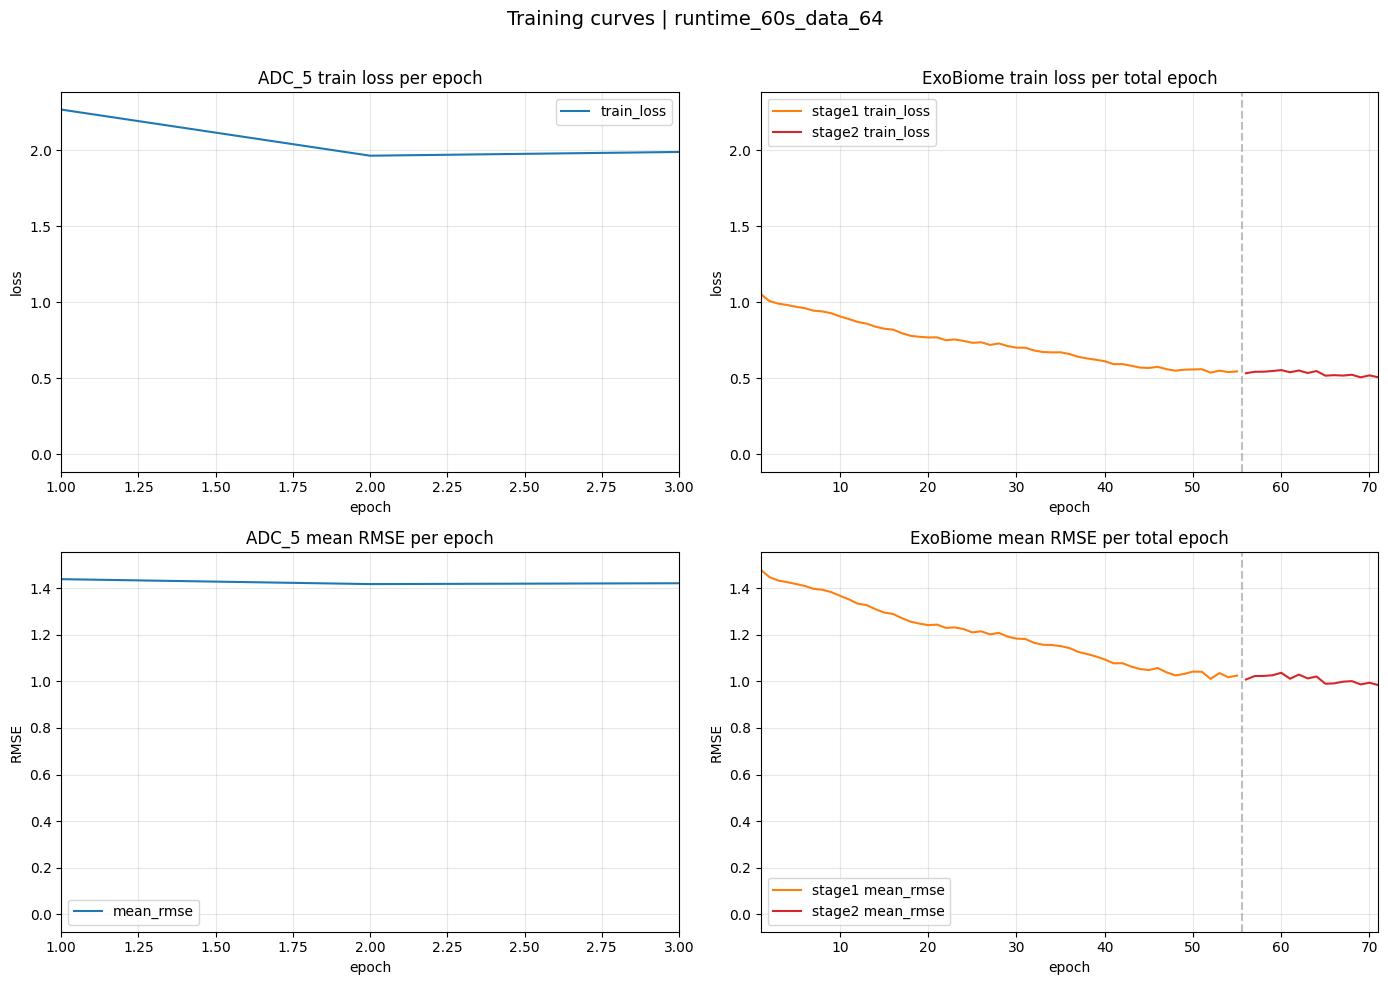

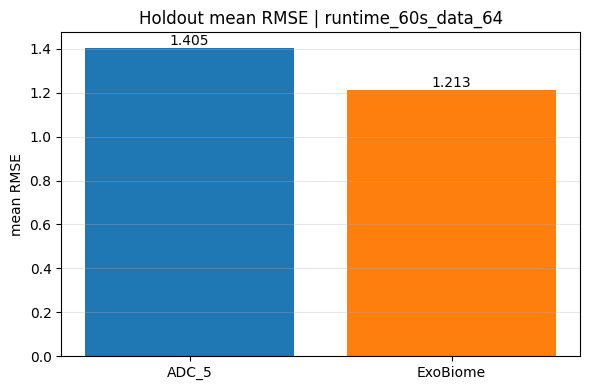

### runtime_60s_data_128

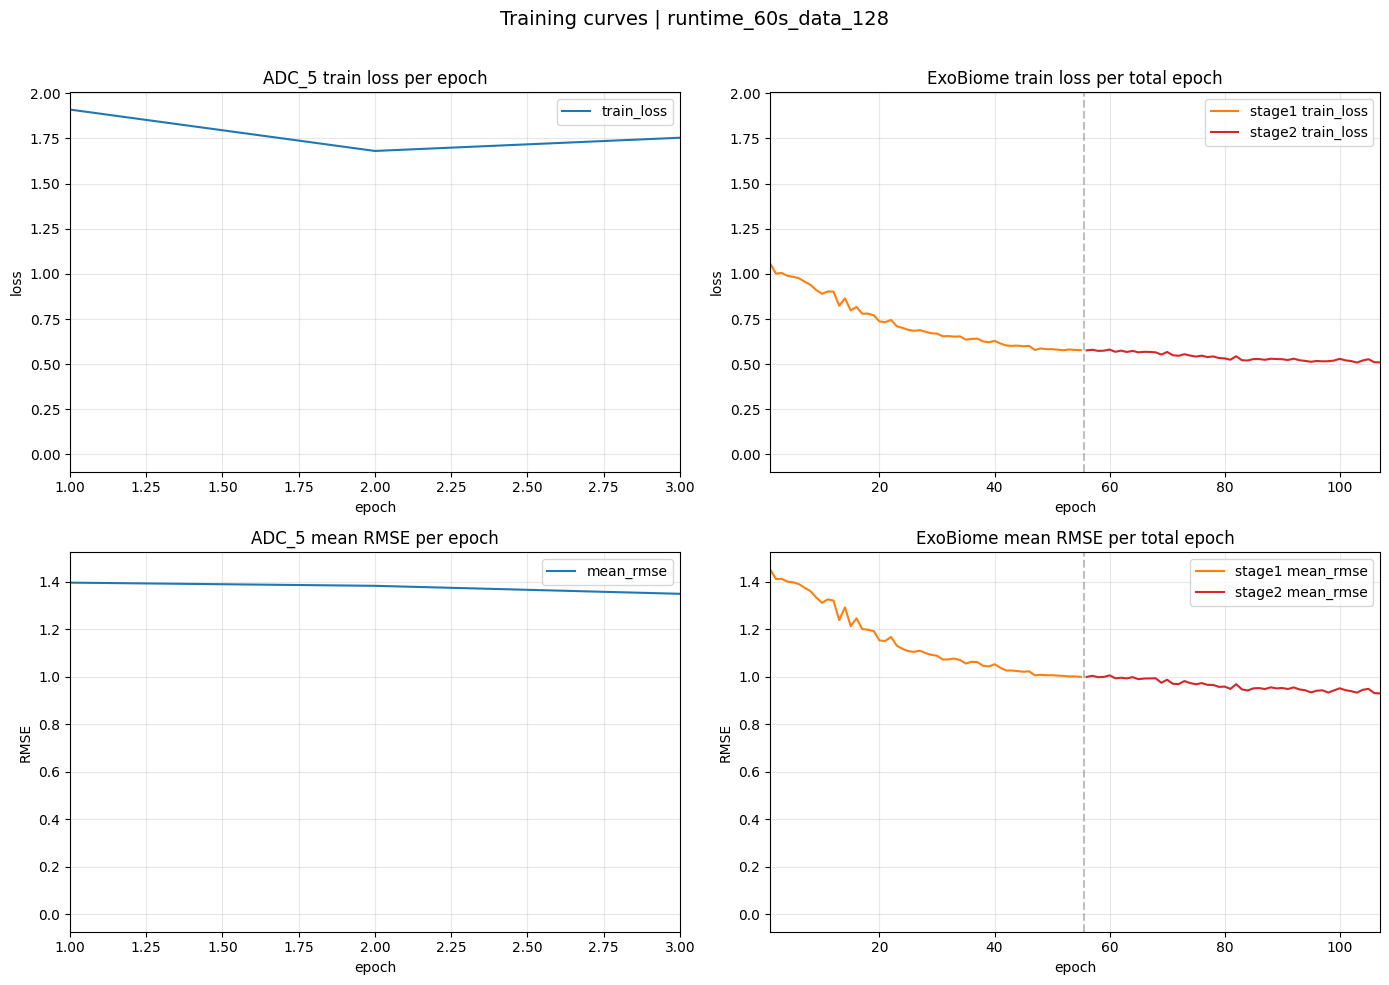

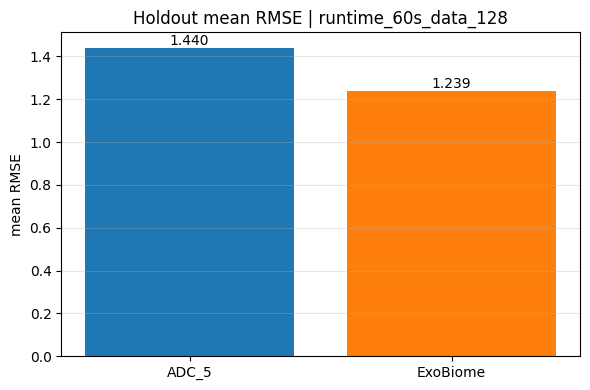

### runtime_60s_data_256

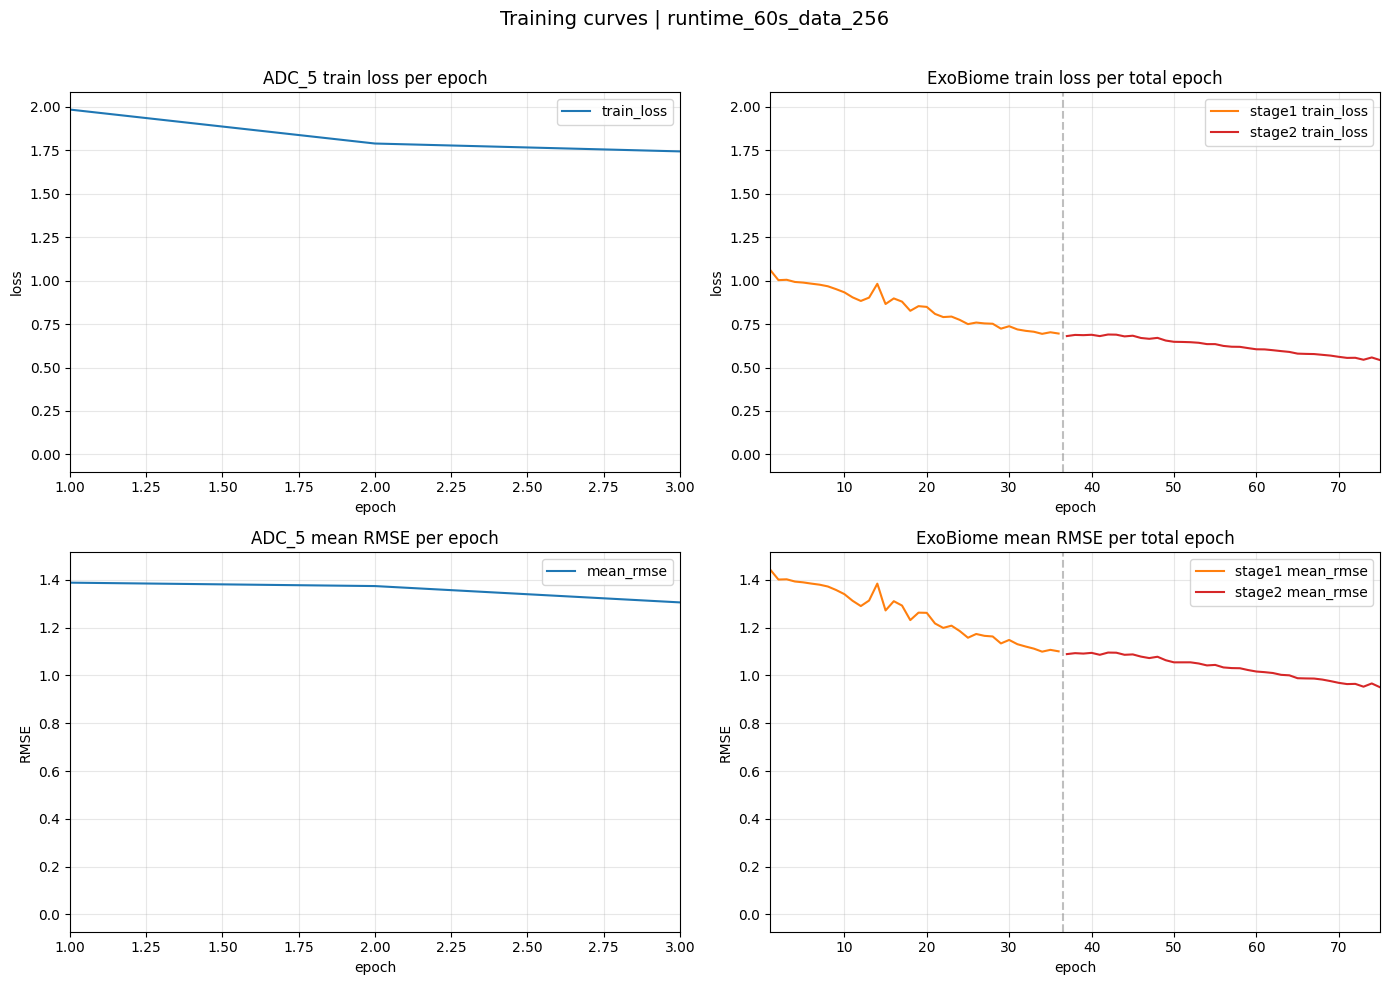

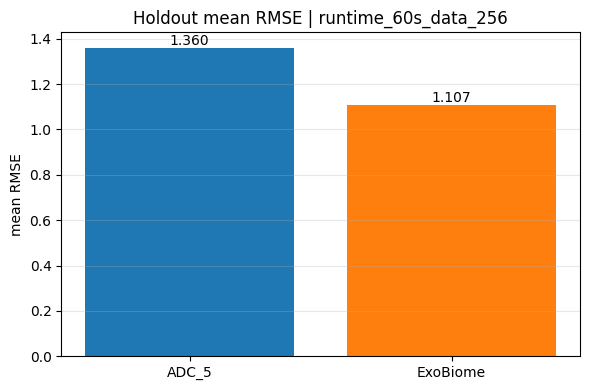

### runtime_120s_data_64

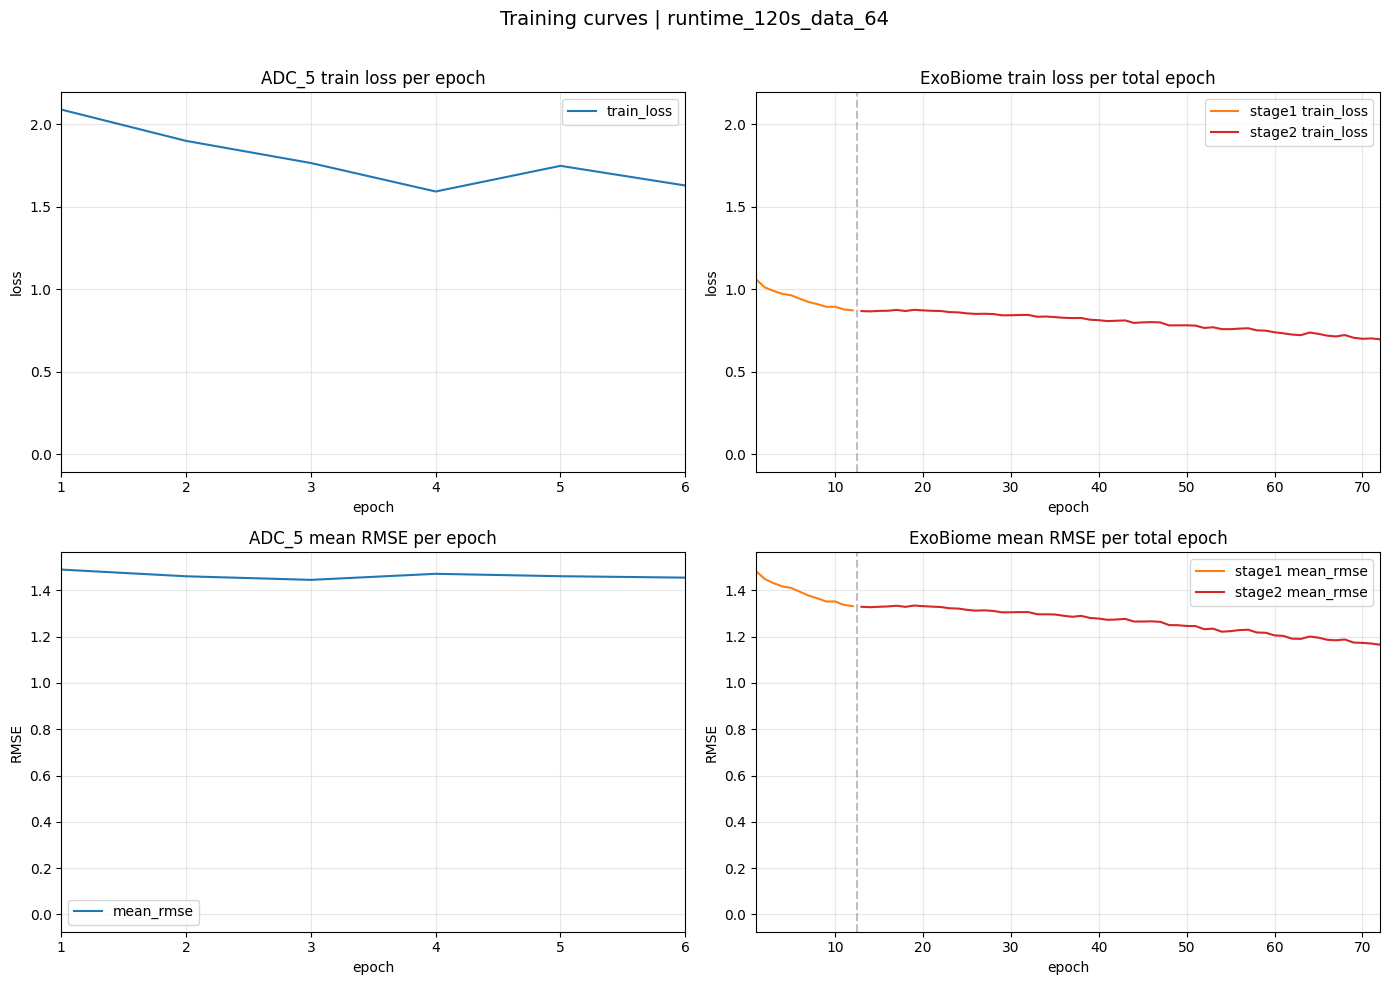

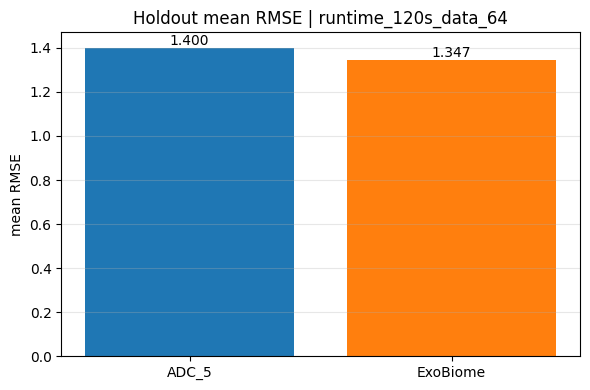

### runtime_120s_data_128

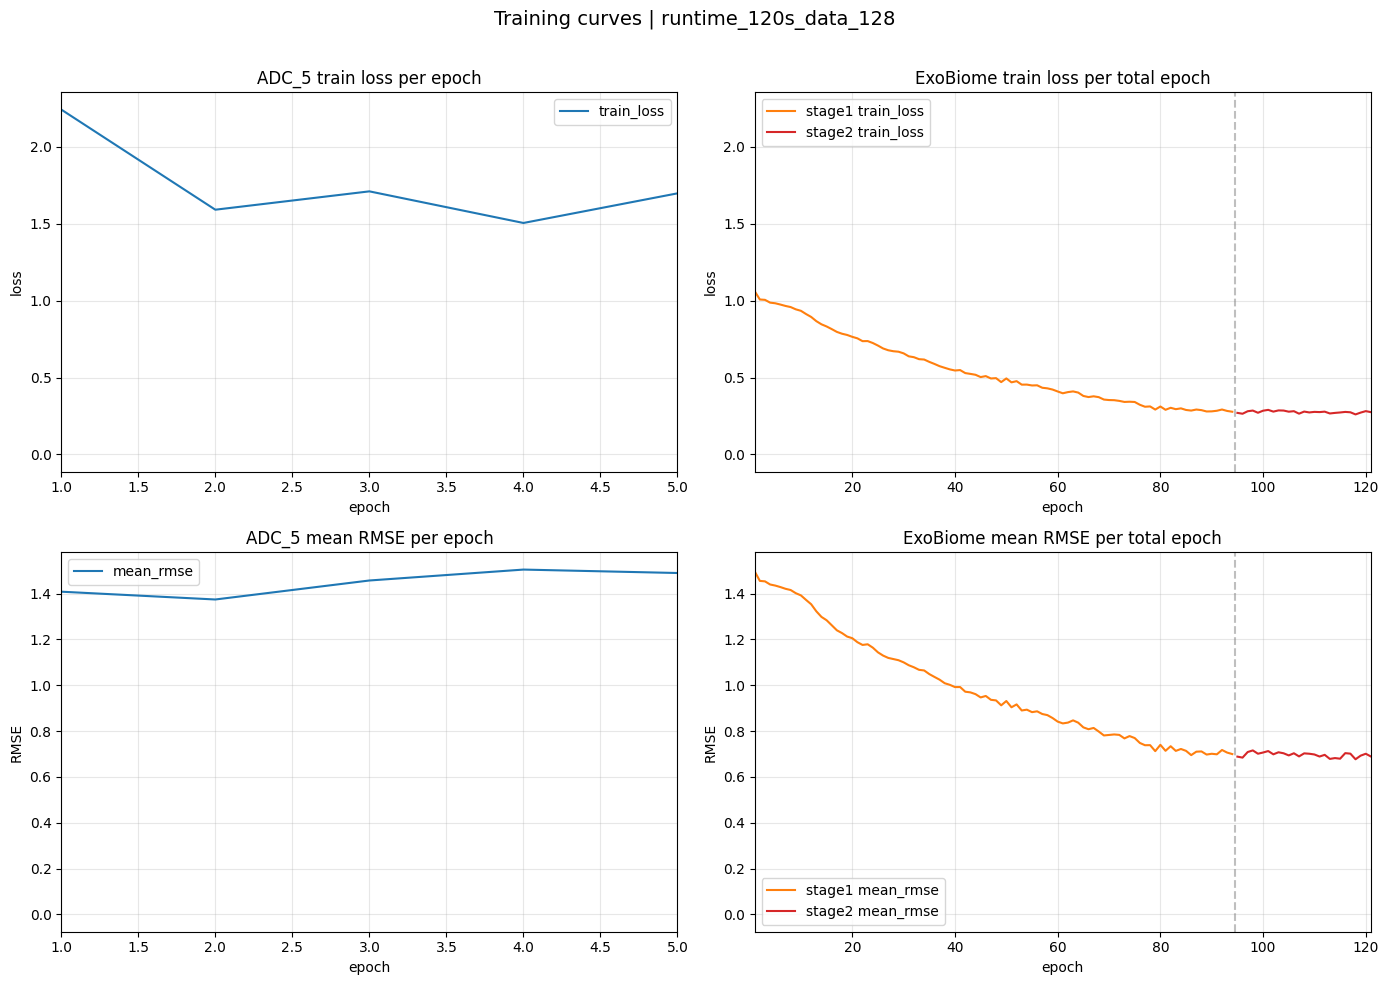

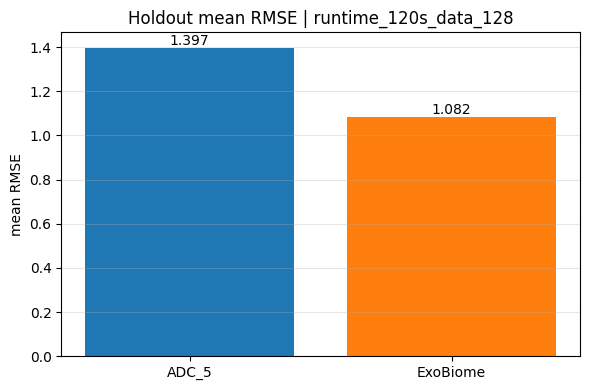

### runtime_120s_data_256

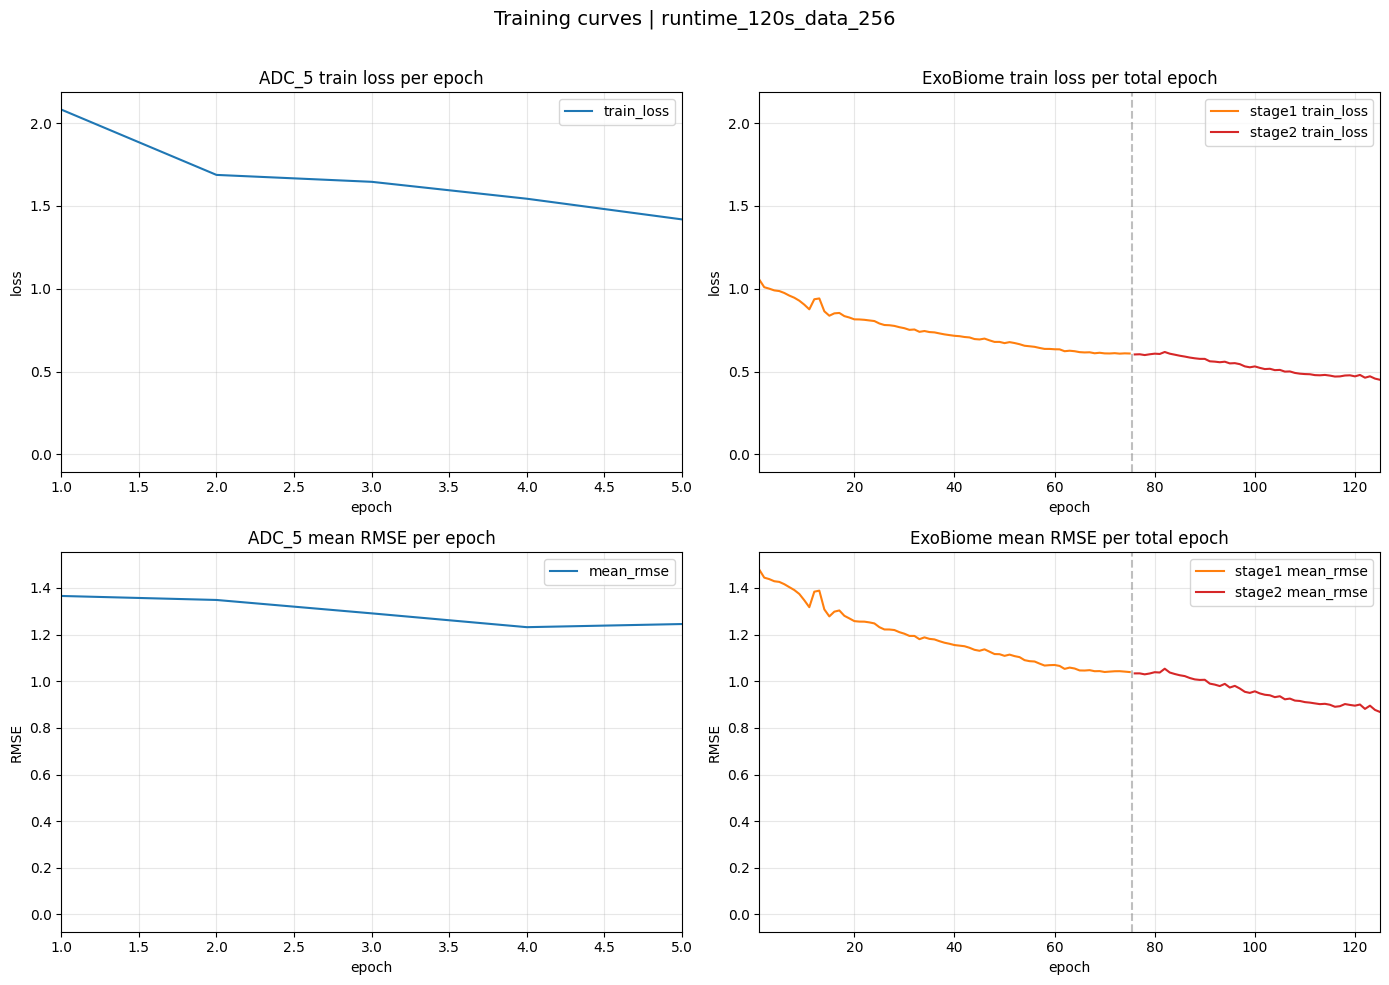

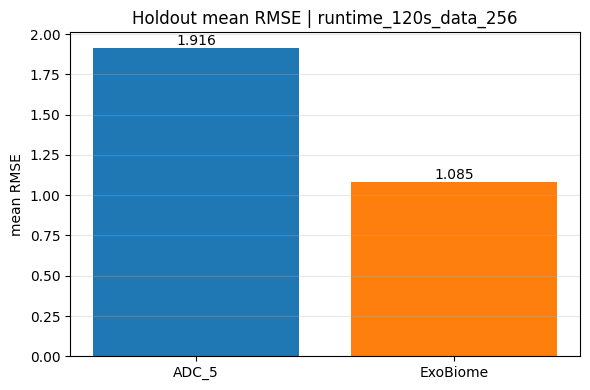

### runtime_300s_data_64

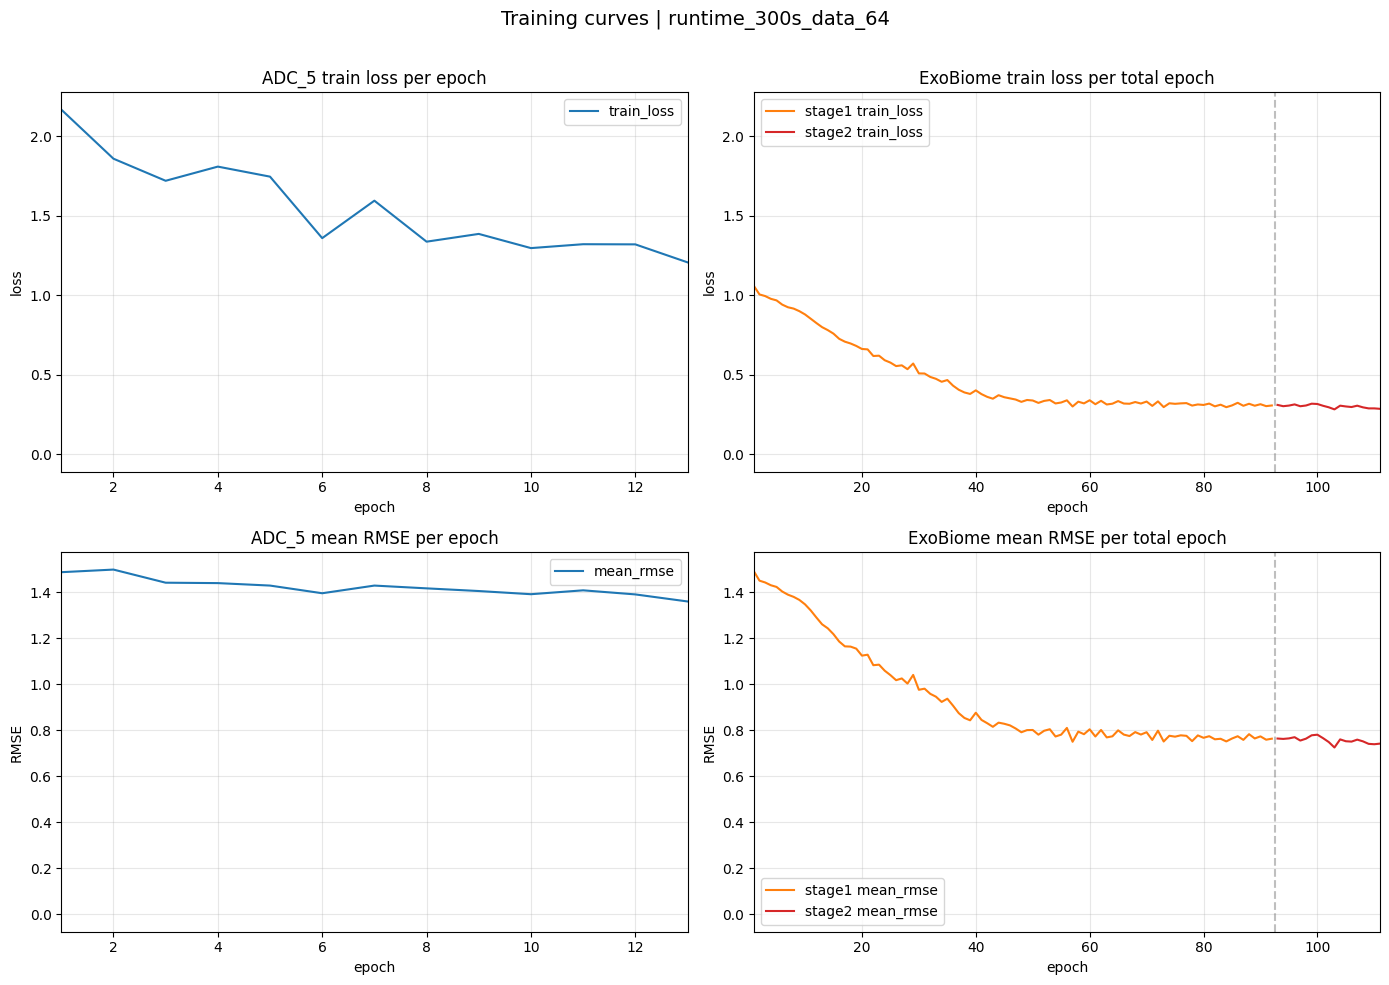

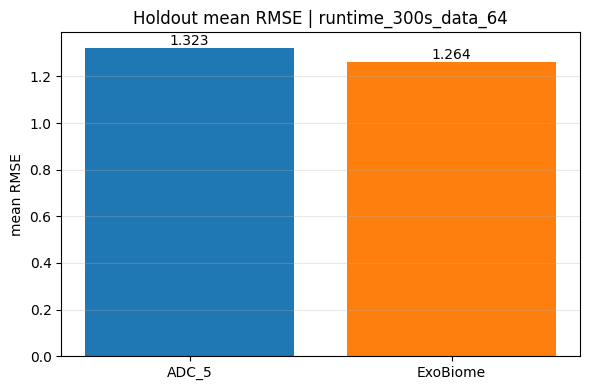

### runtime_300s_data_128

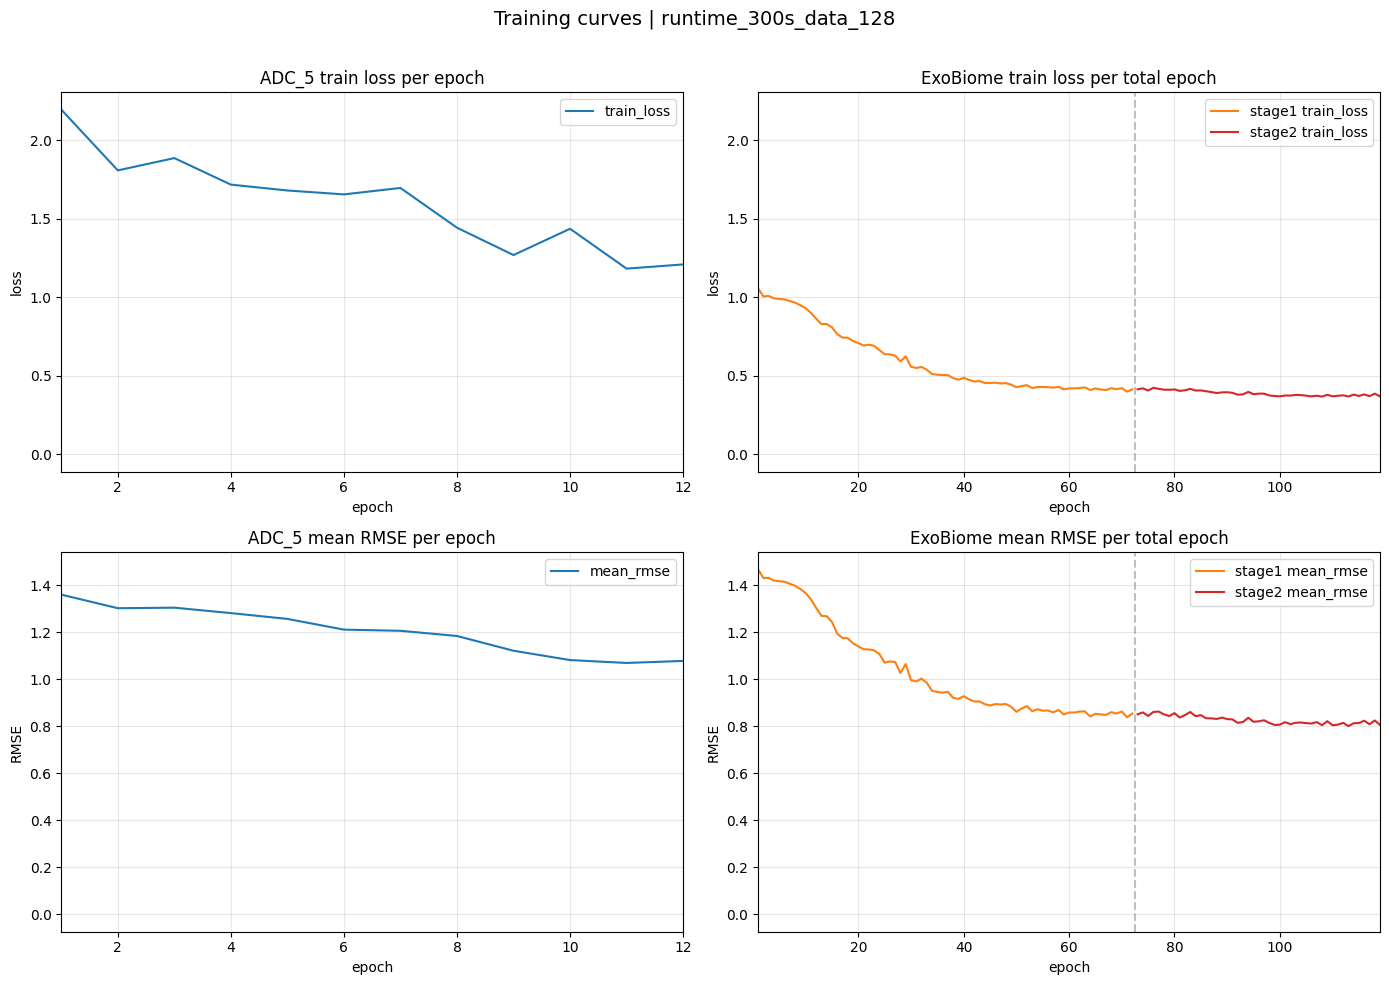

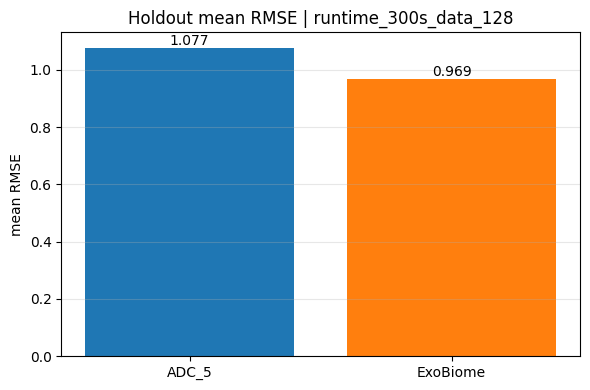

### runtime_300s_data_256

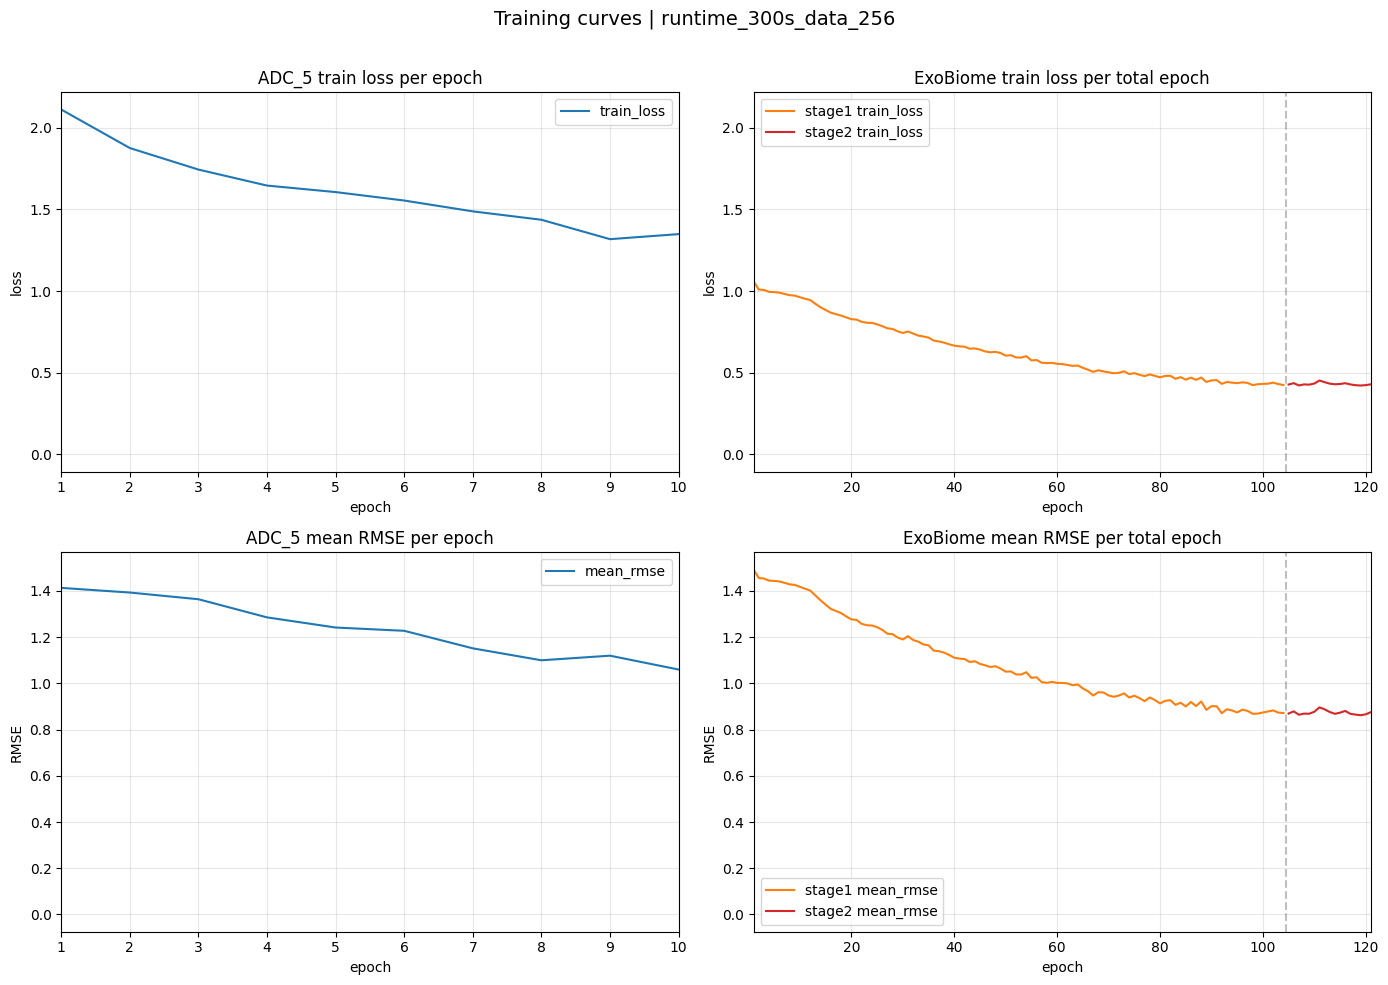

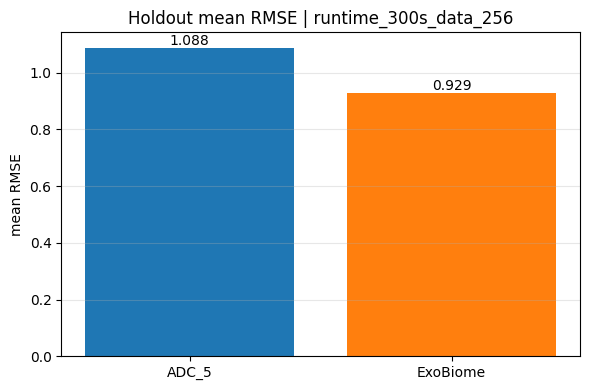

### runtime_400s_data_64

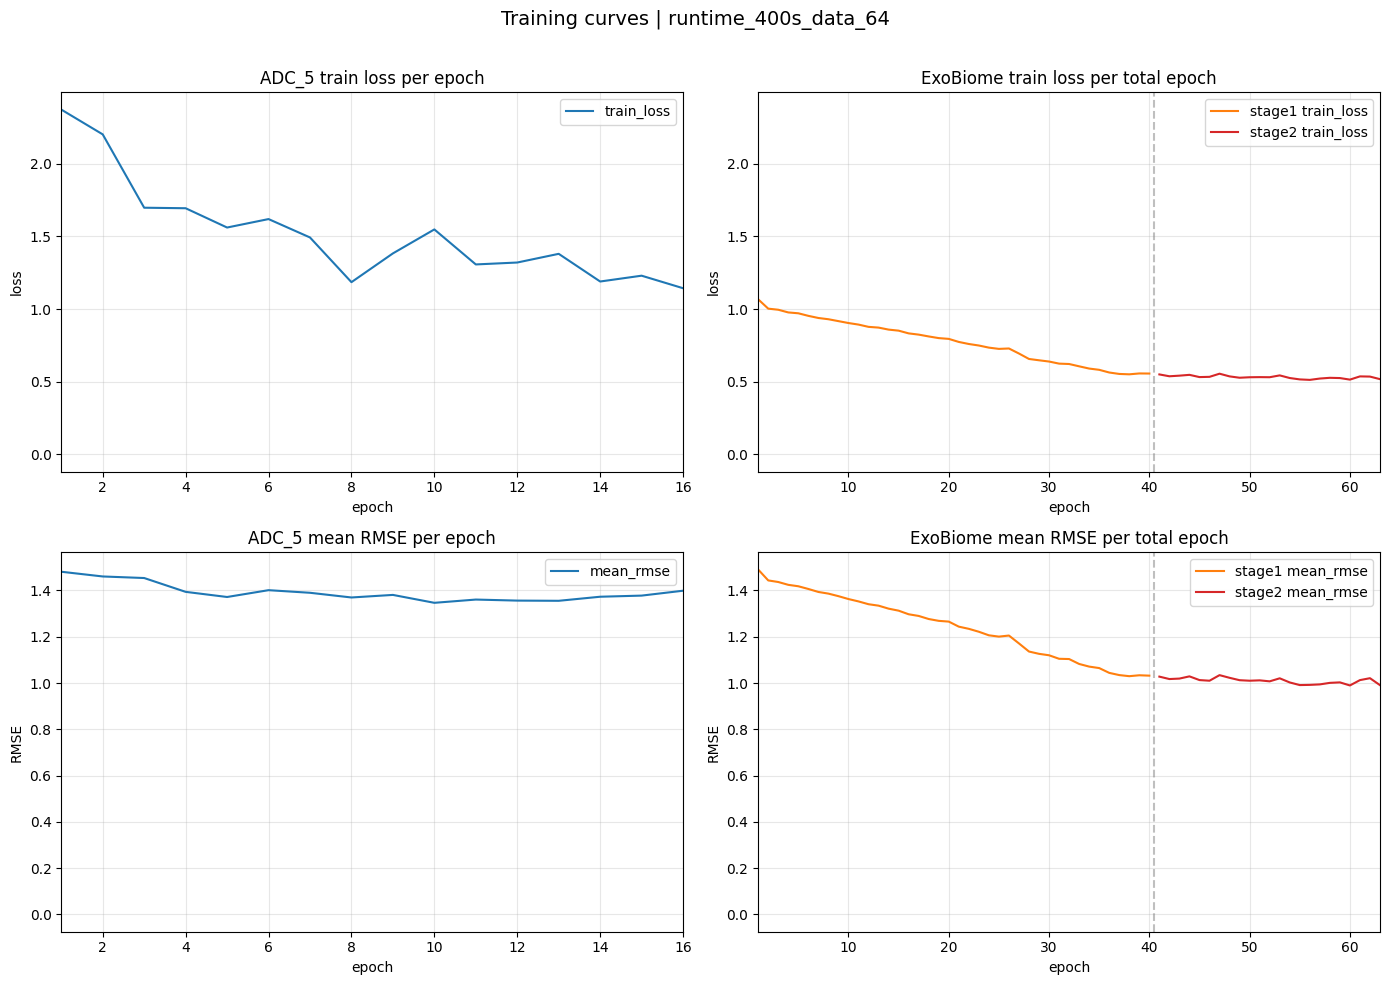

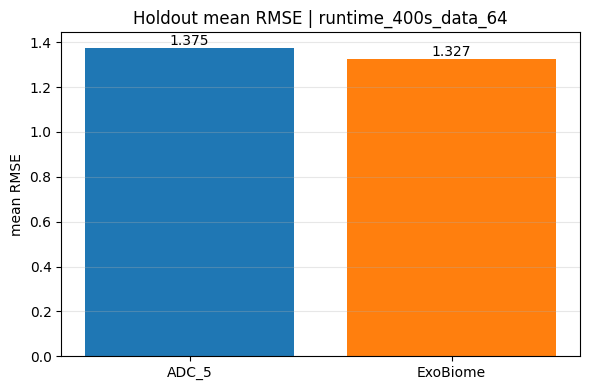

### runtime_400s_data_128

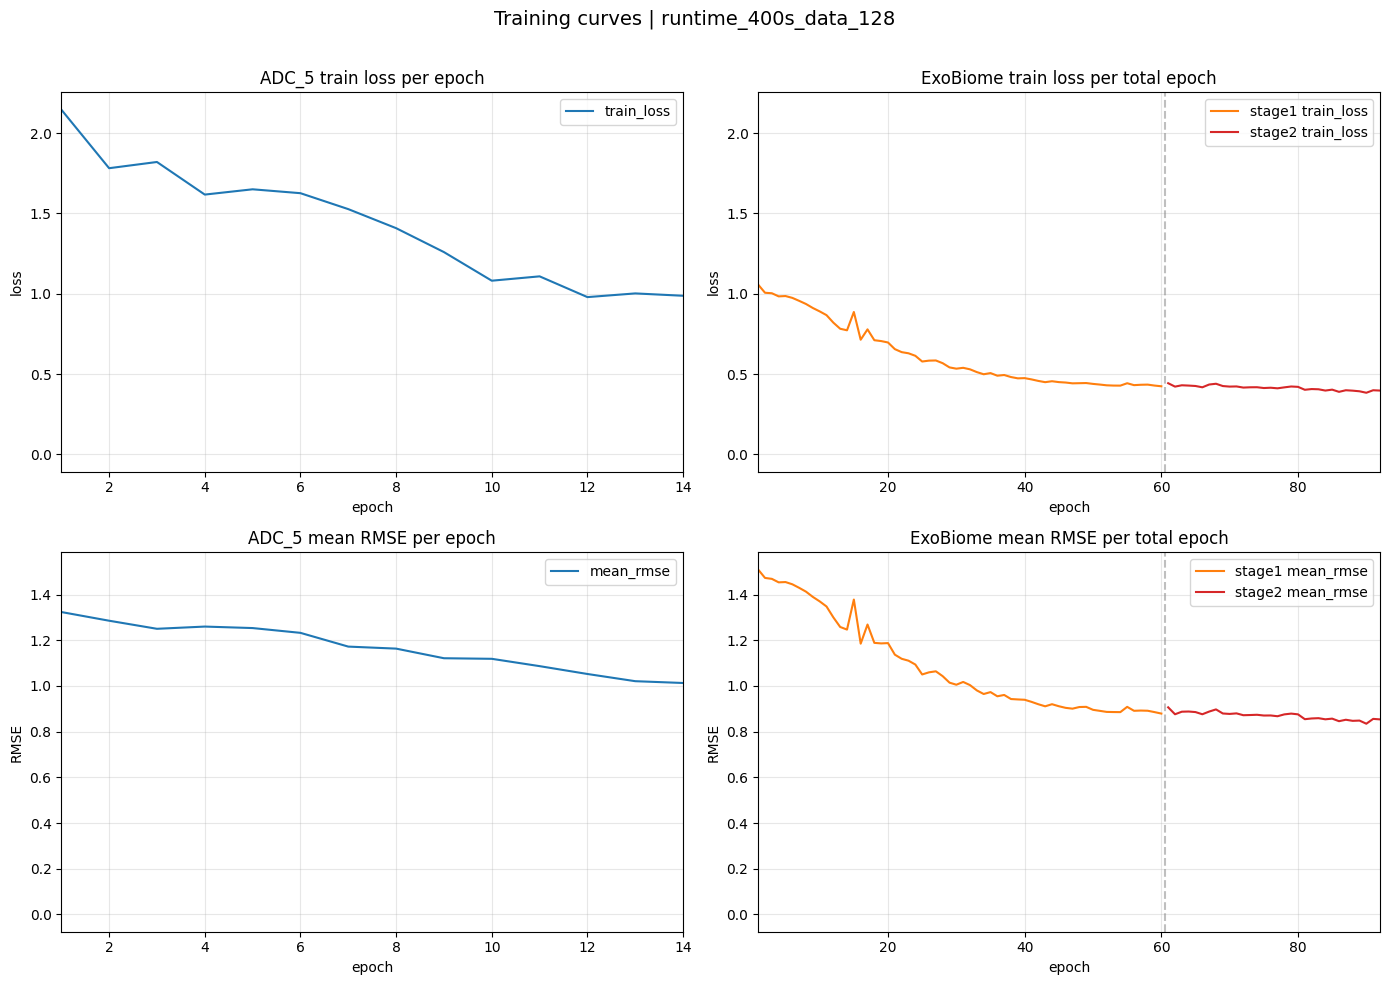

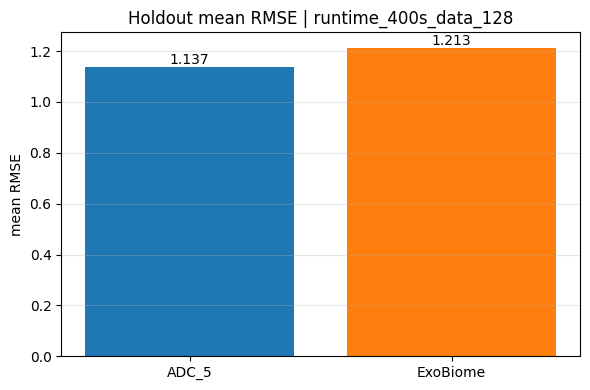

### runtime_400s_data_256

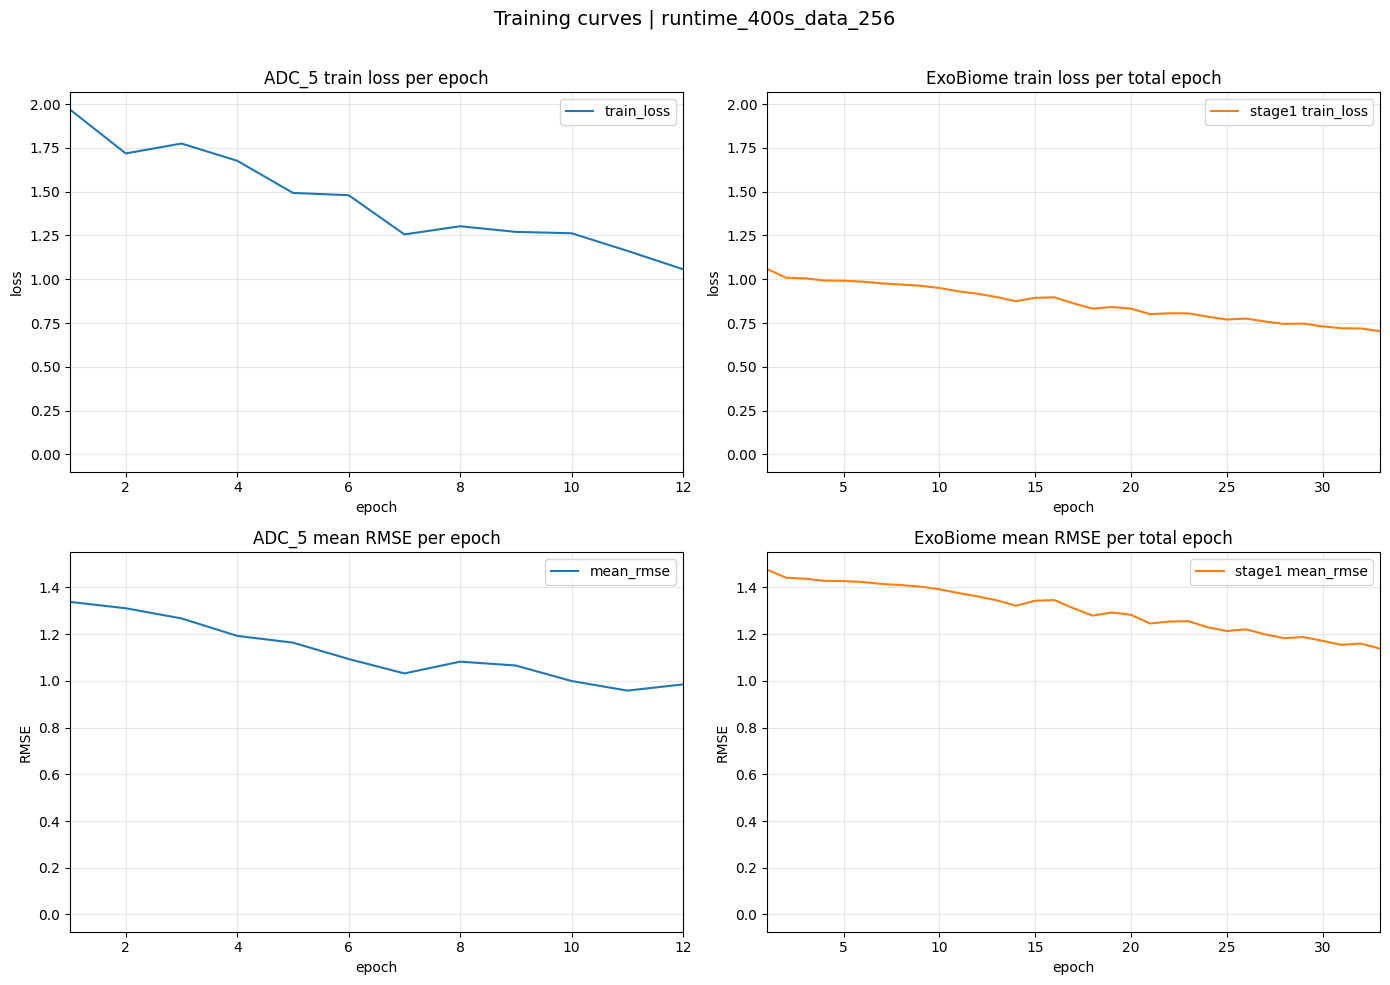

Mean RMSE comparison skipped because one or both final summary files are missing.

In [13]:
# Five post-training plots for every finished condition: four training curves plus final mean RMSE comparison
import re
from pathlib import Path


def discover_condition_dirs(output_root: Path) -> list[Path]:
    direct_conditions = [path for path in output_root.glob("runtime_*") if path.is_dir()]
    if direct_conditions:
        return direct_conditions

    seeded_conditions = []
    for seed_dir in sorted(path for path in output_root.glob("seed_*") if path.is_dir()):
        seeded_conditions.extend(path for path in seed_dir.glob("runtime_*") if path.is_dir())
    return seeded_conditions


def condition_sort_key(condition_dir: Path) -> tuple[int, int, str]:
    match = re.search(r"runtime_(\d+)s_data_(\d+)", condition_dir.name)
    runtime_value = int(match.group(1)) if match else 10**9
    train_rows_value = int(match.group(2)) if match else 10**9
    parent_name = condition_dir.parent.name if condition_dir.parent != PLOT_OUTPUT_ROOT else ""
    return runtime_value, train_rows_value, parent_name


all_condition_dirs = sorted(discover_condition_dirs(PLOT_OUTPUT_ROOT), key=condition_sort_key)
if not all_condition_dirs:
    raise FileNotFoundError(f"No finished condition directories found under {PLOT_OUTPUT_ROOT}")

print(f"Found {len(all_condition_dirs)} finished conditions under {PLOT_OUTPUT_ROOT}")

for condition_dir in all_condition_dirs:
    codex_stage1_history_path = condition_dir / "codex" / "stage1_classical" / "history.csv"
    codex_stage2_history_path = condition_dir / "codex" / "stage2_hybrid" / "history.csv"
    codex_stage2_summary_path = condition_dir / "codex" / "stage2_hybrid" / "run_summary.json"
    fmpe_history_path = condition_dir / "fmpe" / "history.txt"
    fmpe_rmse_path = condition_dir / "fmpe" / "validation_rmse.jsonl"
    fmpe_holdout_metrics_path = condition_dir / "fmpe" / "holdout_regression_metrics.json"
    fmpe_posterior_selection_path = condition_dir / "fmpe" / "posterior_selection.json"

    codex_stage1_history = pd.read_csv(codex_stage1_history_path) if codex_stage1_history_path.exists() else pd.DataFrame()
    codex_stage2_history = pd.read_csv(codex_stage2_history_path) if codex_stage2_history_path.exists() else pd.DataFrame()

    if fmpe_history_path.exists():
        fmpe_history = pd.read_csv(
            fmpe_history_path,
            sep=r"\s+",
            header=None,
            names=["epoch", "train_loss", "val_loss", "lr"],
            engine="python",
        )
    else:
        fmpe_history = pd.DataFrame(columns=["epoch", "train_loss", "val_loss", "lr"])

    if fmpe_rmse_path.exists():
        fmpe_rmse_records = [json.loads(line) for line in fmpe_rmse_path.read_text().splitlines() if line.strip()]
        fmpe_rmse = pd.DataFrame(fmpe_rmse_records)
    else:
        fmpe_rmse = pd.DataFrame(columns=["epoch", "mean_rmse_mean", "median_rmse_mean"])

    codex_holdout_mean_rmse = None
    if codex_stage2_summary_path.exists():
        codex_holdout_mean_rmse = float(json.loads(codex_stage2_summary_path.read_text())["holdout_rmse_mean"])

    fmpe_holdout_mean_rmse = None
    if fmpe_holdout_metrics_path.exists() and fmpe_posterior_selection_path.exists():
        fmpe_holdout_metrics = json.loads(fmpe_holdout_metrics_path.read_text())
        selected_point_estimate = json.loads(fmpe_posterior_selection_path.read_text()).get("selected_point_estimate", "mean")
        fmpe_holdout_mean_rmse = float(fmpe_holdout_metrics[selected_point_estimate]["rmse_mean"])

    codex_stage1_epoch_axis = codex_stage1_history["epoch"] if not codex_stage1_history.empty else pd.Series(dtype=float)
    stage1_last_epoch = int(codex_stage1_epoch_axis.max()) if not codex_stage1_history.empty else 0
    codex_stage2_epoch_axis = codex_stage2_history["epoch"] + stage1_last_epoch if not codex_stage2_history.empty else pd.Series(dtype=float)

    condition_label = condition_dir.relative_to(PLOT_OUTPUT_ROOT)
    display(Markdown(f"### {condition_label}"))

    def padded_limits(*series_list, lower_bound=None):
        values = []
        for series in series_list:
            if series is None:
                continue
            array = np.asarray(series, dtype=float)
            finite = array[np.isfinite(array)]
            if finite.size:
                values.append(finite)
        if not values:
            return None
        combined = np.concatenate(values)
        vmin = float(combined.min())
        vmax = float(combined.max())
        if lower_bound is not None:
            vmin = min(vmin, lower_bound)
        if np.isclose(vmin, vmax):
            pad = 0.05 * (abs(vmin) if vmin else 1.0)
        else:
            pad = 0.05 * (vmax - vmin)
        return vmin - pad, vmax + pad

    fmpe_loss_x = fmpe_history["epoch"] if not fmpe_history.empty else pd.Series(dtype=float)
    fmpe_rmse_x = fmpe_rmse["epoch"] if not fmpe_rmse.empty else pd.Series(dtype=float)

    adc5_xmax = max(
        [series.max() for series in [fmpe_loss_x, fmpe_rmse_x] if not series.empty],
        default=1,
    )
    exobiome_xmax = max(
        [series.max() for series in [codex_stage1_epoch_axis, codex_stage2_epoch_axis] if not series.empty],
        default=1,
    )
    adc5_xlim = (1, max(2, int(adc5_xmax)))
    exobiome_xlim = (1, max(2, int(exobiome_xmax)))
    loss_ylim = padded_limits(
        fmpe_history["train_loss"] if not fmpe_history.empty else None,
        codex_stage1_history["train_loss"] if not codex_stage1_history.empty else None,
        codex_stage2_history["train_loss"] if not codex_stage2_history.empty else None,
        lower_bound=0.0,
    )
    rmse_ylim = padded_limits(
        fmpe_rmse["mean_rmse_mean"] if not fmpe_rmse.empty else None,
        codex_stage1_history["train_rmse_mean"] if not codex_stage1_history.empty else None,
        codex_stage2_history["train_rmse_mean"] if not codex_stage2_history.empty else None,
        lower_bound=0.0,
    )

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"Training curves | {condition_label}", fontsize=14)

    ax = axes[0, 0]
    if not fmpe_history.empty:
        ax.plot(fmpe_history["epoch"], fmpe_history["train_loss"], label="train_loss", color="tab:blue")
    ax.set_title("ADC_5 train loss per epoch")
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.set_xlim(*adc5_xlim)
    if loss_ylim is not None:
        ax.set_ylim(*loss_ylim)
    ax.grid(True, alpha=0.3)
    if ax.lines:
        ax.legend()

    ax = axes[0, 1]
    if not codex_stage1_history.empty:
        ax.plot(codex_stage1_epoch_axis, codex_stage1_history["train_loss"], label="stage1 train_loss", color="tab:orange")
    if not codex_stage2_history.empty:
        ax.plot(codex_stage2_epoch_axis, codex_stage2_history["train_loss"], label="stage2 train_loss", color="tab:red")
    if not codex_stage1_history.empty and not codex_stage2_history.empty:
        ax.axvline(stage1_last_epoch + 0.5, color="gray", linestyle="--", alpha=0.5)
    ax.set_title("ExoBiome train loss per total epoch")
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.set_xlim(*exobiome_xlim)
    if loss_ylim is not None:
        ax.set_ylim(*loss_ylim)
    ax.grid(True, alpha=0.3)
    if ax.lines:
        ax.legend()

    ax = axes[1, 0]
    if not fmpe_rmse.empty:
        ax.plot(fmpe_rmse["epoch"], fmpe_rmse["mean_rmse_mean"], label="mean_rmse", color="tab:blue")
    ax.set_title("ADC_5 mean RMSE per epoch")
    ax.set_xlabel("epoch")
    ax.set_ylabel("RMSE")
    ax.set_xlim(*adc5_xlim)
    if rmse_ylim is not None:
        ax.set_ylim(*rmse_ylim)
    ax.grid(True, alpha=0.3)
    if ax.lines:
        ax.legend()

    ax = axes[1, 1]
    if not codex_stage1_history.empty:
        ax.plot(codex_stage1_epoch_axis, codex_stage1_history["train_rmse_mean"], label="stage1 mean_rmse", color="tab:orange")
    if not codex_stage2_history.empty:
        ax.plot(codex_stage2_epoch_axis, codex_stage2_history["train_rmse_mean"], label="stage2 mean_rmse", color="tab:red")
    if not codex_stage1_history.empty and not codex_stage2_history.empty:
        ax.axvline(stage1_last_epoch + 0.5, color="gray", linestyle="--", alpha=0.5)
    ax.set_title("ExoBiome mean RMSE per total epoch")
    ax.set_xlabel("epoch")
    ax.set_ylabel("RMSE")
    ax.set_xlim(*exobiome_xlim)
    if rmse_ylim is not None:
        ax.set_ylim(*rmse_ylim)
    ax.grid(True, alpha=0.3)
    if ax.lines:
        ax.legend()

    plt.tight_layout(rect=(0, 0, 1, 0.97))
    plt.show()

    if codex_holdout_mean_rmse is not None and fmpe_holdout_mean_rmse is not None:
        fig, ax = plt.subplots(figsize=(6, 4))
        labels = ["ADC_5", "ExoBiome"]
        values = [fmpe_holdout_mean_rmse, codex_holdout_mean_rmse]
        colors = ["tab:blue", "tab:orange"]
        bars = ax.bar(labels, values, color=colors)
        ax.set_title(f"Holdout mean RMSE | {condition_label}")
        ax.set_ylabel("mean RMSE")
        ax.grid(axis="y", alpha=0.3)
        for bar, value in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width() / 2, value, f"{value:.3f}", ha="center", va="bottom")
        plt.tight_layout()
        plt.show()
    else:
        display(Markdown("Mean RMSE comparison skipped because one or both final summary files are missing."))